# French Property Intelligence
## 04 — Advanced Models

### Objective

This notebook evaluates nonlinear gradient-boosted tree models for residential property valuation.

Separate models are developed for:

1. houses (`Maison`);
2. apartments (`Appartement`).

The experiments reuse the frozen train and validation datasets created in Notebook 02. The test datasets remain untouched.

### Experimental strategy

The first LightGBM experiments use exactly the same five predictors as the Ridge baselines:

- `surface_habitable`;
- `n_pieces`;
- `vefa`;
- `latitude`;
- `longitude`.

Keeping the feature set unchanged isolates the effect of **model capacity**: any improvement over Ridge can initially be attributed to the nonlinear modeling approach rather than additional information.

After establishing this nonlinear benchmark, additional features may be evaluated through controlled validation experiments.

### Evaluation

The primary metric remains **MAE**.

Secondary metrics are:

- RMSE;
- R².

All model-selection and feature-selection decisions are based on validation data. The test datasets remain untouched until the final modeling strategy has been selected.

### Production constraint

The final modeling approach must remain compatible with serialization, MLflow experiment tracking, AWS S3 artifact storage, and prediction through the production FastAPI service.

In [61]:
# PURPOSE:
# Import the libraries required for the first LightGBM experiment
# and establish reproducible project configuration.

from pathlib import Path

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import pyproj
import joblib


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("LightGBM version:", lgb.__version__)
print("Project root:", PROJECT_ROOT)

LightGBM version: 4.7.0
Project root: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence


In [2]:
# PURPOSE:
# Load only the frozen HOUSE training and validation populations.
#
# The test population is deliberately not loaded because it must remain
# untouched during model development and model-selection decisions.

house_train = pd.read_parquet(
    DATA_PROCESSED_DIR / "houses_train.parquet"
)

house_val = pd.read_parquet(
    DATA_PROCESSED_DIR / "houses_validation.parquet"
)

print("House train:     ", house_train.shape)
print("House validation:", house_val.shape)

House train:      (1630944, 11)
House validation: (349176, 11)


In [3]:
# PURPOSE:
# Reproduce exactly the same five-feature contract used by Ridge.
#
# This makes the first LightGBM vs Ridge comparison methodologically fair:
# the model changes, but the information supplied to the model does not.

TARGET = "prix"

MODEL_FEATURES = [
    "surface_habitable",
    "n_pieces",
    "vefa",
    "latitude",
    "longitude",
]

X_house_train = house_train[MODEL_FEATURES].copy()
y_house_train = house_train[TARGET]

X_house_val = house_val[MODEL_FEATURES].copy()
y_house_val = house_val[TARGET]

print("X train:", X_house_train.shape)
print("X validation:", X_house_val.shape)

print("\nMissing values in training:")
print(X_house_train.isna().sum())

X train: (1630944, 5)
X validation: (349176, 5)

Missing values in training:
surface_habitable       0
n_pieces             1652
vefa                    0
latitude                0
longitude               0
dtype: int64


In [4]:
# PURPOSE:
# Use the same evaluation definitions as Notebook 03 so LightGBM
# performance is directly comparable with the established baselines.

def evaluate_regression(y_true, y_pred, model_name, property_type):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    return {
        "property_type": property_type,
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

## 2. Initial House LightGBM model

The first LightGBM experiment uses the same five predictors as Ridge.

LightGBM is particularly relevant for this problem because it can learn:

- nonlinear relationships between habitable surface and price;
- nonlinear geographic effects from latitude and longitude;
- interactions between property characteristics and location;
- patterns involving missing values without requiring explicit imputation.

A conservative initial configuration is used rather than extensive hyperparameter tuning.

A relatively large maximum number of boosting iterations is specified together with **early stopping** on validation MAE. Training therefore stops when additional trees no longer improve the primary validation metric.

In [5]:
# PURPOSE:
# Define the first nonlinear House valuation model.
#
# This is a controlled benchmark rather than a tuned final model.
# It uses exactly the same five predictors as Ridge so that the first
# comparison isolates the effect of nonlinear model capacity.
#
# Early stopping during fitting will determine how many boosting
# iterations are useful on the frozen validation population.

house_lgbm = lgb.LGBMRegressor(
    objective="regression_l1",   # optimize absolute error
    metric="mae",

    n_estimators=2000,           # upper limit; early stopping can stop earlier
    learning_rate=0.05,

    num_leaves=31,
    max_depth=-1,

    subsample=0.8,
    subsample_freq=1,            # activate row subsampling at each iteration
    colsample_bytree=0.8,

    random_state=RANDOM_STATE,
    n_jobs=-1,
)

house_lgbm

,learning_rate,0.05
,n_estimators,2000
,objective,'regression_l1'
,subsample,0.8
,subsample_freq,1
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,metric,'mae'
,boosting_type,'gbdt'
,num_leaves,31


In [6]:
# PURPOSE:
# Fit House LightGBM using training data while monitoring validation MAE.
#
# The validation population is used only to determine when boosting
# should stop; the test population remains completely untouched.

house_lgbm.fit(
    X_house_train,
    y_house_train,

    eval_set=[
        (X_house_val, y_house_val)
    ],

    eval_metric="mae",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        ),
        lgb.log_evaluation(period=100),
    ],
)

print(
    "\nBest iteration:",
    house_lgbm.best_iteration_
)

c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008829 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 784
[LightGBM] [Info] Number of data points in the train set: 1630944, number of used features: 5
[LightGBM] [Info] Start training from score 195600.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 87496
[200]	valid_0's l1: 82451.1
[300]	valid_0's l1: 80315.2
[400]	valid_0's l1: 78726.1
[500]	valid_0's l1: 77638.7
[600]	valid_0's l1: 76666.2
[700]	valid_0's l1: 75882.6
[800]	valid_0's l1: 75212.7
[900]	valid_0's l1: 74729.8
[1000]	valid_0's l1: 74339.6
[1100]	valid_0's l1: 73940.6
[1200]	valid_0's l1: 73640.1
[1300]	valid_0's l1: 73394.3
[1400]	valid_0's l1: 73165.6
[1500]	valid_0's l1: 72968
[1600]	valid_0's l1: 72796.2
[1700]	valid_0's l1: 72592.1
[1800]	valid_0's l1: 72424.7
[1900]	valid_0's l

In [7]:
# PURPOSE:
# Evaluate the nonlinear House model on exactly the same validation
# population used for the Ridge baseline.

house_lgbm_pred = house_lgbm.predict(
    X_house_val,
    num_iteration=house_lgbm.best_iteration_
)

house_lgbm_result = evaluate_regression(
    y_true=y_house_val,
    y_pred=house_lgbm_pred,
    model_name="LightGBM",
    property_type="House",
)

print(
    f"House | LightGBM | "
    f"MAE: €{house_lgbm_result['MAE']:,.0f} | "
    f"RMSE: €{house_lgbm_result['RMSE']:,.0f} | "
    f"R²: {house_lgbm_result['R2']:.4f}"
)

House | LightGBM | MAE: €72,137 | RMSE: €151,137 | R²: 0.6366


In [8]:
# PURPOSE:
# Quantify the value of nonlinear modeling while holding the feature
# set and validation population constant.
#
# The Ridge and naive reference metrics are loaded from the persisted
# Notebook 03 results rather than duplicated manually. This keeps the
# comparison reproducible and avoids stale hard-coded benchmark values.

baseline_metrics = pd.read_csv(
    PROJECT_ROOT / "outputs" / "metrics" / "baseline_model_metrics.csv"
)

HOUSE_RIDGE_MAE = baseline_metrics.loc[
    (baseline_metrics["property_type"] == "House")
    & (baseline_metrics["model"] == "Ridge"),
    "MAE",
].iloc[0]

HOUSE_NAIVE_MAE = baseline_metrics.loc[
    (baseline_metrics["property_type"] == "House")
    & (baseline_metrics["model"] == "Naive median"),
    "MAE",
].iloc[0]

lgbm_mae = house_lgbm_result["MAE"]

vs_ridge_euros = HOUSE_RIDGE_MAE - lgbm_mae
vs_ridge_pct = (
    vs_ridge_euros / HOUSE_RIDGE_MAE * 100
)

vs_naive_euros = HOUSE_NAIVE_MAE - lgbm_mae
vs_naive_pct = (
    vs_naive_euros / HOUSE_NAIVE_MAE * 100
)

print(f"Naive MAE:          €{HOUSE_NAIVE_MAE:,.0f}")
print(f"Ridge MAE:          €{HOUSE_RIDGE_MAE:,.0f}")
print(f"LightGBM MAE:       €{lgbm_mae:,.0f}")

print(
    f"\nImprovement vs Ridge: "
    f"€{vs_ridge_euros:,.0f} ({vs_ridge_pct:.2f}%)"
)

print(
    f"Improvement vs naive: "
    f"€{vs_naive_euros:,.0f} ({vs_naive_pct:.2f}%)"
)

Naive MAE:          €133,559
Ridge MAE:          €124,039
LightGBM MAE:       €72,137

Improvement vs Ridge: €51,902 (41.84%)
Improvement vs naive: €61,422 (45.99%)


### Initial House LightGBM result

The initial House LightGBM model achieved:

- **MAE:** approximately €72,137
- **RMSE:** approximately €151,137
- **R²:** 0.6366
- **MAE improvement vs Ridge:** 41.84%
- **MAE improvement vs naive median:** 45.99%

This represents a substantial improvement in the project's primary model-selection metric.

Because LightGBM and Ridge received exactly the same five predictors and were evaluated on the same frozen validation population, this controlled comparison provides evidence that nonlinear relationships and feature interactions are important for the house valuation problem.

In particular, geographic coordinates have limited expressive power in a linear model because their effect on property value is unlikely to be globally linear. A gradient-boosted tree model can instead partition geographic space and combine location with characteristics such as habitable surface, number of rooms, and VEFA status.

The secondary metrics support the same conclusion: validation RMSE decreases to approximately **€151,137**, while R² increases to **0.6366**. The remaining gap between MAE and RMSE indicates that some observations still produce substantially larger errors than the typical absolute error, so error-distribution diagnostics remain relevant.

The model reached the configured maximum of **2,000 boosting iterations**, with validation MAE still improving. Early stopping therefore did not identify an optimum within the configured iteration budget. This experiment should consequently be interpreted as a strong nonlinear benchmark rather than as evidence that 2,000 iterations is the optimal model complexity.

Further experiments will evaluate whether controlled changes to model configuration or feature representation can improve validation MAE while preserving the same leakage-safe validation framework.

In [9]:
# PURPOSE:
# Load the frozen Apartment training and validation populations.
#
# The Apartment test population remains untouched.

apartment_train = pd.read_parquet(
    DATA_PROCESSED_DIR / "apartments_train.parquet"
)

apartment_val = pd.read_parquet(
    DATA_PROCESSED_DIR / "apartments_validation.parquet"
)

X_apartment_train = apartment_train[MODEL_FEATURES].copy()
y_apartment_train = apartment_train[TARGET]

X_apartment_val = apartment_val[MODEL_FEATURES].copy()
y_apartment_val = apartment_val[TARGET]

print("Apartment train:", X_apartment_train.shape)
print("Apartment validation:", X_apartment_val.shape)

print("\nMissing values:")
print(X_apartment_train.isna().sum())

Apartment train: (1263001, 5)
Apartment validation: (269977, 5)

Missing values:
surface_habitable       0
n_pieces             1149
vefa                    0
latitude                0
longitude               0
dtype: int64


In [10]:
# PURPOSE:
# Evaluate the same nonlinear modeling strategy on Apartments.
#
# Keeping the initial LightGBM configuration unchanged makes the
# House and Apartment experiments easier to compare.

apartment_lgbm = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",

    n_estimators=2000,
    learning_rate=0.05,

    num_leaves=31,
    max_depth=-1,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=RANDOM_STATE,
    n_jobs=-1,
)

apartment_lgbm.fit(
    X_apartment_train,
    y_apartment_train,

    eval_X=X_apartment_val,
    eval_y=y_apartment_val,

    eval_metric="mae",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        ),
        lgb.log_evaluation(period=100),
    ],
)

print(
    "\nBest iteration:",
    apartment_lgbm.best_iteration_
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010985 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 783
[LightGBM] [Info] Number of data points in the train set: 1263001, number of used features: 5
[LightGBM] [Info] Start training from score 166000.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 63425.9
[200]	valid_0's l1: 59306.1
[300]	valid_0's l1: 57485.2
[400]	valid_0's l1: 56372.7
[500]	valid_0's l1: 55411.9
[600]	valid_0's l1: 54840.5
[700]	valid_0's l1: 54333.8
[800]	valid_0's l1: 54000.9
[900]	valid_0's l1: 53677.8
[1000]	valid_0's l1: 53301.7
[1100]	valid_0's l1: 53002.3
[1200]	valid_0's l1: 52794
[1300]	valid_0's l1: 52553.2
[1400]	valid_0's l1: 52346.9
[1500]	valid_0's l1: 52058.7
[1600]	valid_0's l1: 51876.6
[1700]	valid_0's l1: 51697.3
[1800]	valid_0's l1: 51548.4
[1900]	valid_0's

In [11]:
# PURPOSE:
# Measure Apartment LightGBM performance using the same metrics
# used throughout the project.

apartment_lgbm_pred = apartment_lgbm.predict(
    X_apartment_val,
    num_iteration=apartment_lgbm.best_iteration_
)

apartment_lgbm_result = evaluate_regression(
    y_true=y_apartment_val,
    y_pred=apartment_lgbm_pred,
    model_name="LightGBM",
    property_type="Apartment",
)

print(
    f"Apartment | LightGBM | "
    f"MAE: €{apartment_lgbm_result['MAE']:,.0f} | "
    f"RMSE: €{apartment_lgbm_result['RMSE']:,.0f} | "
    f"R²: {apartment_lgbm_result['R2']:.4f}"
)

Apartment | LightGBM | MAE: €51,291 | RMSE: €114,133 | R²: 0.7881


In [12]:
# PURPOSE:
# Quantify the value of nonlinear modeling for Apartment valuation while
# holding the feature set and validation population constant.
#
# The Ridge and naive reference metrics are loaded from the persisted
# Notebook 03 results rather than duplicated manually. This keeps the
# comparison reproducible and consistent with the House analysis.

APARTMENT_RIDGE_MAE = baseline_metrics.loc[
    (baseline_metrics["property_type"] == "Apartment")
    & (baseline_metrics["model"] == "Ridge"),
    "MAE",
].iloc[0]

APARTMENT_NAIVE_MAE = baseline_metrics.loc[
    (baseline_metrics["property_type"] == "Apartment")
    & (baseline_metrics["model"] == "Naive median"),
    "MAE",
].iloc[0]

lgbm_mae = apartment_lgbm_result["MAE"]

vs_ridge_euros = APARTMENT_RIDGE_MAE - lgbm_mae
vs_ridge_pct = (
    vs_ridge_euros / APARTMENT_RIDGE_MAE * 100
)

vs_naive_euros = APARTMENT_NAIVE_MAE - lgbm_mae
vs_naive_pct = (
    vs_naive_euros / APARTMENT_NAIVE_MAE * 100
)

print(f"Naive MAE:          €{APARTMENT_NAIVE_MAE:,.0f}")
print(f"Ridge MAE:          €{APARTMENT_RIDGE_MAE:,.0f}")
print(f"LightGBM MAE:       €{lgbm_mae:,.0f}")

print(
    f"\nImprovement vs Ridge: "
    f"€{vs_ridge_euros:,.0f} ({vs_ridge_pct:.2f}%)"
)

print(
    f"Improvement vs naive: "
    f"€{vs_naive_euros:,.0f} ({vs_naive_pct:.2f}%)"
)

Naive MAE:          €122,966
Ridge MAE:          €122,592
LightGBM MAE:       €51,291

Improvement vs Ridge: €71,301 (58.16%)
Improvement vs naive: €71,675 (58.29%)


### Initial Apartment LightGBM result

The initial Apartment LightGBM model achieved:

- **MAE:** approximately €51,291
- **RMSE:** approximately €114,133
- **R²:** 0.7881
- **MAE improvement vs Ridge:** 58.16%
- **MAE improvement vs naive median:** 58.29%

This represents a substantial improvement in the project's primary model-selection metric.

The Apartment Ridge model produced only a marginal MAE improvement over the naive median baseline (€122,966 to €122,592). In contrast, using exactly the same five predictors and the same frozen validation population, LightGBM reduces validation MAE to approximately **€51,291**, an improvement of more than 58% relative to both baselines.

Because the information supplied to Ridge and LightGBM is identical, this controlled comparison provides strong evidence that nonlinear relationships and feature interactions are important for Apartment valuation. In particular, gradient-boosted trees can model nonlinear geographic structure and interactions between location and property characteristics that are not represented by the linear Ridge specification.

The secondary metrics support the same conclusion: validation RMSE decreases to approximately **€114,133**, while R² reaches **0.7881**. The difference between MAE and RMSE nevertheless indicates that some transactions still generate substantially larger prediction errors than the typical absolute error, which motivates further error-distribution analysis.

As with the House model, validation MAE was still improving when the configured maximum of **2,000 boosting iterations** was reached. Early stopping therefore did not identify an optimum within the configured iteration budget. The 2,000-round model should consequently be interpreted as a strong nonlinear benchmark rather than as the optimal LightGBM configuration.

Further controlled experiments will determine whether changes to model configuration or feature representation can improve validation MAE while preserving the same leakage-safe evaluation framework.

In [13]:
# PURPOSE:
# Consolidate all baseline and nonlinear validation results into one table.
#
# This table provides quantitative evidence for model-family selection.
# Baseline metrics come directly from the persisted Notebook 03 results,
# while LightGBM metrics come from the current Notebook 04 evaluation.
#
# Within each property type, all three models are evaluated on the same
# frozen validation population. Ridge and LightGBM also use exactly the
# same five-feature contract, enabling a controlled model-family comparison.

comparison_rows = []

for property_type in ["House", "Apartment"]:
    for model_name in ["Naive median", "Ridge"]:

        baseline_row = baseline_metrics.loc[
            (baseline_metrics["property_type"] == property_type)
            & (baseline_metrics["model"] == model_name)
        ].iloc[0]

        comparison_rows.append({
            "Property type": property_type,
            "Model": model_name,
            "MAE": baseline_row["MAE"],
            "RMSE": baseline_row["RMSE"],
            "R2": baseline_row["R2"],
        })

comparison_rows.extend([
    {
        "Property type": "House",
        "Model": "LightGBM",
        "MAE": house_lgbm_result["MAE"],
        "RMSE": house_lgbm_result["RMSE"],
        "R2": house_lgbm_result["R2"],
    },
    {
        "Property type": "Apartment",
        "Model": "LightGBM",
        "MAE": apartment_lgbm_result["MAE"],
        "RMSE": apartment_lgbm_result["RMSE"],
        "R2": apartment_lgbm_result["R2"],
    },
])

model_comparison = pd.DataFrame(comparison_rows)

# Display a clean presentation version while preserving the underlying
# numerical values in model_comparison for later calculations and export.
model_comparison_display = model_comparison.copy()

model_comparison_display["MAE"] = (
    model_comparison_display["MAE"].round(0).astype(int)
)

model_comparison_display["RMSE"] = (
    model_comparison_display["RMSE"].round(0).astype(int)
)

model_comparison_display["R2"] = (
    model_comparison_display["R2"].round(4)
)

model_comparison_display

,Property type,Model,MAE,RMSE,R2
0,House,Naive median,133559,256471,-0.0465
1,House,Ridge,124039,223815,0.2031
2,Apartment,Naive median,122966,255155,-0.0590
3,Apartment,Ridge,122592,212375,0.2663
4,House,LightGBM,72137,151137,0.6366
5,Apartment,LightGBM,51291,114133,0.7881


## 3. Validation error diagnostics

Before tuning model complexity or adding features, validation residuals are examined to identify where the current LightGBM benchmarks still make their largest errors.

Aggregate MAE alone does not reveal whether prediction errors are broadly distributed across transactions or concentrated within a smaller subset of difficult observations.

These diagnostics are descriptive only. They are performed exclusively on the frozen validation populations, do not alter the modeling dataset, and do not remove observations. The held-out test populations remain untouched.

In [14]:
# PURPOSE:
# Examine the distribution of validation prediction errors for the
# current LightGBM benchmarks.
#
# Absolute errors show the magnitude of prediction mistakes, while
# signed residuals help identify systematic under- or overprediction.
#
# These diagnostics are descriptive only: no observations are removed
# and no model-selection decision is made from this cell alone.

def error_diagnostics(y_true, y_pred, property_type):

    errors = pd.DataFrame({
        "actual_price": np.asarray(y_true),
        "predicted_price": np.asarray(y_pred),
    })

    # Positive residual  -> model underpredicted the transaction price.
    # Negative residual  -> model overpredicted the transaction price.
    errors["residual"] = (
        errors["actual_price"]
        - errors["predicted_price"]
    )

    errors["absolute_error"] = (
        errors["residual"].abs()
    )

    print(f"--- {property_type} ---")

    print("\nAbsolute error distribution:")
    print(
        errors["absolute_error"]
        .quantile([
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
            0.999,
            1.00,
        ])
    )

    print("\nSigned residual distribution:")
    print(
        errors["residual"]
        .quantile([
            0.01,
            0.10,
            0.50,
            0.90,
            0.99,
        ])
    )

    print("\nActual price distribution:")
    print(
        errors["actual_price"]
        .quantile([
            0.50,
            0.90,
            0.95,
            0.99,
            0.999,
            1.00,
        ])
    )

    return errors

In [15]:
# PURPOSE:
# Compare House and Apartment validation-error distributions.

house_errors = error_diagnostics(
    y_house_val,
    house_lgbm_pred,
    "House",
)

apartment_errors = error_diagnostics(
    y_apartment_val,
    apartment_lgbm_pred,
    "Apartment",
)

--- House ---

Absolute error distribution:
0.500    4.343720e+04
0.750    8.355573e+04
0.900    1.471920e+05
0.950    2.121289e+05
0.990    4.987718e+05
0.999    1.684918e+06
1.000    1.074705e+07
Name: absolute_error, dtype: float64

Signed residual distribution:
0.01   -244495.437693
0.10    -90071.181897
0.50      -323.270197
0.90    106278.121396
0.99    461930.919419
Name: residual, dtype: float64

Actual price distribution:
0.500      195500.00
0.900      456000.00
0.950      605000.00
0.990     1154562.50
0.999     2759203.75
1.000    13000000.00
Name: actual_price, dtype: float64
--- Apartment ---

Absolute error distribution:
0.500    2.838937e+04
0.750    5.743393e+04
0.900    1.064433e+05
0.950    1.588087e+05
0.990    3.887778e+05
0.999    1.284657e+06
1.000    5.780092e+06
Name: absolute_error, dtype: float64

Signed residual distribution:
0.01   -220690.541642
0.10    -63165.840507
0.50      -704.951313
0.90     73643.089590
0.99    306483.635784
Name: residual, dtype: f

### Validation error-distribution findings

The initial LightGBM models do not exhibit a large overall directional bias: median signed residuals are close to zero for both Houses and Apartments.

However, prediction difficulty is unevenly distributed. For Houses, median absolute error is approximately **€43,437**, compared with **€147,192 at the 90th percentile** and **€498,772 at the 99th percentile**. For Apartments, the corresponding values are approximately **€28,389**, **€106,443**, and **€388,778**.

A relatively small upper tail therefore contributes disproportionately to the secondary RMSE metric, although substantial errors also exist below the most extreme observations.

The largest errors occur within the upper end of the remaining transaction-price distribution. These observations are retained because they satisfy the previously defined Cleaning Policy v2; validation diagnostics are not used to introduce additional target-based filtering.

The next diagnostic examines model performance across transaction-price segments to determine whether prediction error increases systematically with property value.

In [16]:
# PURPOSE:
# Determine whether validation errors are concentrated in particular
# transaction-price segments.
#
# Price segments are used for diagnostic analysis only. Actual price is
# the target and is NOT used as a model feature.
#
# No observations are removed and the frozen validation population is
# not modified.

def error_by_price_segment(errors):

    bins = [
        0,
        100_000,
        200_000,
        300_000,
        500_000,
        1_000_000,
        2_000_000,
        np.inf,
    ]

    labels = [
        "<100k",
        "100–200k",
        "200–300k",
        "300–500k",
        "500k–1M",
        "1–2M",
        "2M+",
    ]

    df = errors.copy()

    df["price_segment"] = pd.cut(
        df["actual_price"],
        bins=bins,
        labels=labels,
        right=False,
    )

    result = (
        df.groupby(
            "price_segment",
            observed=True
        )
        .agg(
            transactions=("actual_price", "size"),
            median_price=("actual_price", "median"),
            MAE=("absolute_error", "mean"),
            median_absolute_error=("absolute_error", "median"),
        )
        .reset_index()
    )

    result["share_pct"] = (
        result["transactions"] / len(df) * 100
    )

    # Diagnostic relative-error indicator:
    # median absolute error expressed relative to the median transaction
    # price within each segment.
    #
    # This is not an official model-selection metric; MAE remains primary.
    result["median_error_pct_of_median_price"] = (
        result["median_absolute_error"]
        / result["median_price"]
        * 100
    )

    return result

In [17]:
# PURPOSE:
# Compare House and Apartment LightGBM validation accuracy across
# transaction-price segments.
#
# We inspect both absolute euro error and a segment-level relative-error
# indicator to understand whether expensive properties are simply producing
# larger euro errors or are also proportionally more difficult to predict.

house_error_segments = error_by_price_segment(
    house_errors
)

apartment_error_segments = error_by_price_segment(
    apartment_errors
)

print("HOUSE")
display(
    house_error_segments.round({
        "median_price": 0,
        "MAE": 0,
        "median_absolute_error": 0,
        "share_pct": 2,
        "median_error_pct_of_median_price": 2,
    })
)

print("\nAPARTMENT")
display(
    apartment_error_segments.round({
        "median_price": 0,
        "MAE": 0,
        "median_absolute_error": 0,
        "share_pct": 2,
        "median_error_pct_of_median_price": 2,
    })
)

HOUSE


,price_segment,transactions,median_price,MAE,median_absolute_error,share_pct,median_error_pct_of_median_price
0,<100k,64416,65000.0,56158.0,41099.0,18.45,63.23
1,100–200k,112952,150000.0,43527.0,30631.0,32.35,20.42
2,200–300k,80882,240500.0,51948.0,41460.0,23.16,17.24
3,300–500k,62464,365000.0,78288.0,63943.0,17.89,17.52
4,500k–1M,23500,617590.0,171229.0,146105.0,6.73,23.66
5,1–2M,4145,1240000.0,515329.0,475528.0,1.19,38.35
6,2M+,817,2600000.0,1717104.0,1523786.0,0.23,58.61



APARTMENT


,price_segment,transactions,median_price,MAE,median_absolute_error,share_pct,median_error_pct_of_median_price
0,<100k,60594,70000.0,34219.0,18863.0,22.44,26.95
1,100–200k,103845,145000.0,31423.0,22513.0,38.46,15.53
2,200–300k,53031,239000.0,45413.0,35075.0,19.64,14.68
3,300–500k,33437,364900.0,73980.0,57245.0,12.39,15.69
4,500k–1M,15048,627500.0,133797.0,99040.0,5.57,15.78
5,1–2M,3297,1248043.0,296978.0,212935.0,1.22,17.06
6,2M+,725,2550000.0,877704.0,617868.0,0.27,24.23


### Price-segment diagnostic findings

Validation performance is not uniform across the transaction-price distribution.

For **Houses**, relative prediction error is lowest across the central market, particularly between approximately €200,000 and €500,000. Performance deteriorates substantially at both ends of the distribution. Properties below €100,000 represent 18.45% of House validation transactions and have a median absolute error equivalent to approximately 63% of the segment median price. At the upper end, the relative error indicator increases from approximately 24% for €500,000–€1 million properties to 38% for €1–€2 million and 59% above €2 million.

For **Apartments**, performance is more stable across the central market. Between approximately €100,000 and €1 million, median absolute error remains around 15–16% of segment median transaction price. Relative error increases for properties above €1 million and for the below-€100,000 segment.

The upper-price segments represent only a small proportion of validation transactions but generate much larger absolute euro errors and therefore contribute disproportionately to aggregate MAE and especially RMSE. However, the low-price segments also show elevated relative error and contain a materially larger share of transactions.

These diagnostics do not justify additional target-based filtering. All observations satisfy the previously defined Cleaning Policy v2, which remains frozen. Instead, the results indicate that the current five-feature representation does not capture valuation factors equally well across all parts of the residential market.

The next stage therefore focuses on controlled model and feature improvements using the same frozen training and validation populations. The held-out test populations remain untouched.

## 4. Controlled spatial feature experiments

The initial LightGBM benchmarks demonstrate that nonlinear modeling substantially improves validation performance while using only five predictors. However, location is currently represented exclusively by raw latitude and longitude.

Property markets are highly local, and geographic coordinates alone do not explicitly encode administrative areas or groups of nearby properties. This chapter therefore evaluates whether alternative spatial representations improve valuation accuracy.

The experiments follow a controlled ablation strategy:

1. **Reference model:** the existing five-feature LightGBM benchmark.
2. **Postal-code experiment:** add `code_postal` as a categorical spatial feature.
3. **Virtual-neighborhood experiment:** add a data-driven spatial grouping derived from geographic coordinates.

All experiments use the same frozen training and validation populations and the same primary evaluation metric (MAE). RMSE and R² remain secondary metrics.

Only the spatial representation changes between experiments. The held-out test populations remain untouched.

### Leakage and production constraints

Spatial transformations must be compatible with inference for a previously unseen property.

Any learned spatial transformation is therefore fitted using the training population only. Validation observations are transformed using the already-fitted transformation rather than participating in its construction.

The exact property address is never supplied directly to the valuation model. In production, the address will be geocoded into geographic coordinates, from which the required spatial features can be derived.

A spatial feature is retained only if it provides a measurable validation improvement over the existing benchmark. No feature is assumed to be useful in advance.

### 4.1 Postal code as a categorical spatial feature

The first experiment tests whether postal code provides useful local-market information beyond raw latitude and longitude.

Postal code is treated as a **categorical identifier**, not as a continuous numerical variable. This is important because numerical differences between postal codes do not represent meaningful geographic distances.

The original five predictors are retained. `code_postal` is added as the only experimental feature, allowing its incremental contribution to validation performance to be measured directly.

In [18]:
# PURPOSE:
# Prepare the first controlled spatial-feature experiment.
#
# The existing five-feature LightGBM benchmark is preserved and only
# postal code is added.
#
# Postal code is represented as a pandas categorical feature rather than
# a continuous number because postal codes are geographic identifiers,
# not numerical measurements.

POSTCODE_FEATURES = [
    "surface_habitable",
    "n_pieces",
    "vefa",
    "latitude",
    "longitude",
    "code_postal",
]

X_house_train_postcode = (
    house_train[POSTCODE_FEATURES].copy()
)

X_house_val_postcode = (
    house_val[POSTCODE_FEATURES].copy()
)

X_apartment_train_postcode = (
    apartment_train[POSTCODE_FEATURES].copy()
)

X_apartment_val_postcode = (
    apartment_val[POSTCODE_FEATURES].copy()
)

# Use the categories observed in training as the reference vocabulary.
# Validation data is mapped to the same category definitions.
for X_train, X_val in [
    (X_house_train_postcode, X_house_val_postcode),
    (X_apartment_train_postcode, X_apartment_val_postcode),
]:

    X_train["code_postal"] = (
        X_train["code_postal"].astype("category")
    )

    X_val["code_postal"] = pd.Categorical(
        X_val["code_postal"],
        categories=X_train["code_postal"].cat.categories,
    )

print("HOUSE")
print("Train shape:     ", X_house_train_postcode.shape)
print("Validation shape:", X_house_val_postcode.shape)
print(
    "Training postal codes:",
    X_house_train_postcode["code_postal"].nunique()
)
print(
    "Unknown validation postal codes:",
    X_house_val_postcode["code_postal"].isna().sum()
)

print("\nAPARTMENT")
print("Train shape:     ", X_apartment_train_postcode.shape)
print("Validation shape:", X_apartment_val_postcode.shape)
print(
    "Training postal codes:",
    X_apartment_train_postcode["code_postal"].nunique()
)
print(
    "Unknown validation postal codes:",
    X_apartment_val_postcode["code_postal"].isna().sum()
)

HOUSE
Train shape:      (1630944, 6)
Validation shape: (349176, 6)
Training postal codes: 5631
Unknown validation postal codes: 0

APARTMENT
Train shape:      (1263001, 6)
Validation shape: (269977, 6)
Training postal codes: 4856
Unknown validation postal codes: 370


C:\Users\Alex\AppData\Local\Temp\ipykernel_28108\2752378897.py:47: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_val["code_postal"] = pd.Categorical(


In [19]:
# PURPOSE:
# Verify that postal code is represented as a categorical feature
# before training the LightGBM postcode experiment.

print(X_house_train_postcode["code_postal"].dtype)
print(X_house_val_postcode["code_postal"].dtype)

category
category


In [20]:
# PURPOSE:
# Train the House postal-code ablation model.
#
# This model uses exactly the same LightGBM configuration as the original
# five-feature House benchmark. The only additional predictor is
# code_postal.
#
# code_postal is already stored as a pandas categorical dtype, allowing
# LightGBM to use its native categorical-feature handling.
#
# We deliberately reuse the same eval_set syntax as the original benchmark
# because that training path is already known to work in this environment.
# The LightGBM 4.7 deprecation warning does not invalidate the experiment.

house_lgbm_postcode = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

house_lgbm_postcode.fit(
    X_house_train_postcode,
    y_house_train,
    eval_set=[
        (X_house_val_postcode, y_house_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True,
        ),
        lgb.log_evaluation(period=100),
    ],
)

print(
    "\nBest iteration:",
    house_lgbm_postcode.best_iteration_,
)

c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010206 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5932
[LightGBM] [Info] Number of data points in the train set: 1630944, number of used features: 6
[LightGBM] [Info] Start training from score 195600.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 77354
[200]	valid_0's l1: 72983.4
[300]	valid_0's l1: 71703.7
[400]	valid_0's l1: 71294.1
[500]	valid_0's l1: 71066.2
[600]	valid_0's l1: 70950.6
[700]	valid_0's l1: 70810.7
[800]	valid_0's l1: 70696.1
[900]	valid_0's l1: 70649
[1000]	valid_0's l1: 70576.5
[1100]	valid_0's l

In [21]:
# PURPOSE:
# Evaluate the House postal-code ablation model on the same frozen
# validation population used by the five-feature LightGBM benchmark.
#
# This quantifies the incremental contribution of code_postal while
# keeping the model family, hyperparameters, training population,
# validation population, and original five predictors unchanged.

house_postcode_pred = house_lgbm_postcode.predict(
    X_house_val_postcode
)

house_postcode_result = evaluate_regression(
    y_house_val,
    house_postcode_pred,
    "LightGBM + postcode",
    "House",
)

# Compare directly with the original five-feature LightGBM benchmark.
house_postcode_mae_improvement = (
    house_lgbm_result["MAE"]
    - house_postcode_result["MAE"]
)

house_postcode_mae_improvement_pct = (
    house_postcode_mae_improvement
    / house_lgbm_result["MAE"]
    * 100
)

print("\nHOUSE — POSTCODE ABLATION")

print(
    f"Reference LightGBM MAE: "
    f"€{house_lgbm_result['MAE']:,.0f}"
)

print(
    f"+ Postal code MAE:      "
    f"€{house_postcode_result['MAE']:,.0f}"
)

print(
    f"Absolute improvement:   "
    f"€{house_postcode_mae_improvement:,.0f}"
)

print(
    f"Relative improvement:   "
    f"{house_postcode_mae_improvement_pct:.2f}%"
)

print(
    f"\nRMSE: €{house_postcode_result['RMSE']:,.0f}"
)

print(
    f"R²:   {house_postcode_result['R2']:.4f}"
)


HOUSE — POSTCODE ABLATION
Reference LightGBM MAE: €72,137
+ Postal code MAE:      €70,060
Absolute improvement:   €2,077
Relative improvement:   2.88%

RMSE: €143,378
R²:   0.6729


In [22]:
# PURPOSE:
# Train the Apartment postal-code ablation model.
#
# This experiment mirrors the House postcode experiment.
# The original five predictors and LightGBM configuration remain unchanged;
# code_postal is the only additional feature.
#
# Postal code is already represented as a pandas categorical dtype.
# The 370 validation observations whose postal codes were not observed
# during training remain in the validation population and are handled
# as missing categorical values.
#
# This preserves the frozen validation population and provides a
# controlled measurement of the incremental value of postal code.

apartment_lgbm_postcode = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

apartment_lgbm_postcode.fit(
    X_apartment_train_postcode,
    y_apartment_train,
    eval_set=[
        (X_apartment_val_postcode, y_apartment_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True,
        ),
        lgb.log_evaluation(period=100),
    ],
)

print(
    "\nBest iteration:",
    apartment_lgbm_postcode.best_iteration_,
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.


c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3365
[LightGBM] [Info] Number of data points in the train set: 1263001, number of used features: 6
[LightGBM] [Info] Start training from score 166000.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 54564.7
[200]	valid_0's l1: 51320.5
[300]	valid_0's l1: 50527.5
[400]	valid_0's l1: 50177.6
[500]	valid_0's l1: 49961.7
[600]	valid_0's l1: 49812.2
[700]	valid_0's l1: 49680.3
[800]	valid_0's l1: 49577
[900]	valid_0's l1: 49498.5
[1000]	valid_0's l1: 49420.3
[1100]	valid_0's l1: 49359.1
[1200]	valid_0's l1: 49297
[1300]	valid_0's l1: 49240.4
[1400]	valid_0's l1: 49183.2
[1500]	valid_0's l1: 49130.6
[1600]	valid_0's l1: 49085.1
[1700]	valid_0's l1: 49035.6
[1800]	valid_0's l1: 48997
[1900]	valid_0's l1

In [23]:
# PURPOSE:
# Evaluate the Apartment postal-code ablation model and compare it
# directly with the original five-feature Apartment LightGBM benchmark.
#
# Because the model configuration and frozen validation population are
# unchanged, the comparison isolates the incremental contribution of
# postal code.

apartment_postcode_pred = apartment_lgbm_postcode.predict(
    X_apartment_val_postcode
)

apartment_postcode_result = evaluate_regression(
    y_apartment_val,
    apartment_postcode_pred,
    "LightGBM + postcode",
    "Apartment",
)

apartment_postcode_mae_improvement = (
    apartment_lgbm_result["MAE"]
    - apartment_postcode_result["MAE"]
)

apartment_postcode_mae_improvement_pct = (
    apartment_postcode_mae_improvement
    / apartment_lgbm_result["MAE"]
    * 100
)

print("\nAPARTMENT — POSTCODE ABLATION")

print(
    f"Reference LightGBM MAE: "
    f"€{apartment_lgbm_result['MAE']:,.0f}"
)

print(
    f"+ Postal code MAE:      "
    f"€{apartment_postcode_result['MAE']:,.0f}"
)

print(
    f"Absolute improvement:   "
    f"€{apartment_postcode_mae_improvement:,.0f}"
)

print(
    f"Relative improvement:   "
    f"{apartment_postcode_mae_improvement_pct:.2f}%"
)

print(
    f"\nRMSE: €{apartment_postcode_result['RMSE']:,.0f}"
)

print(
    f"R²:   {apartment_postcode_result['R2']:.4f}"
)


APARTMENT — POSTCODE ABLATION
Reference LightGBM MAE: €51,291
+ Postal code MAE:      €48,913
Absolute improvement:   €2,378
Relative improvement:   4.64%

RMSE: €110,233
R²:   0.8023


#### Postal-code experiment results

Adding postal code as a categorical spatial feature improves validation performance for both property types.

For **Houses**, MAE decreases from approximately **€72,137 to €70,060**, corresponding to an improvement of **€2,077 (2.88%)**. RMSE decreases to approximately **€143,378**, while R² increases from **0.6366 to 0.6729**.

For **Apartments**, MAE decreases from approximately **€51,291 to €48,913**, corresponding to an improvement of **€2,378 (4.64%)**. RMSE decreases to approximately **€110,233**, while R² increases from **0.7881 to 0.8023**.

Because the training and validation populations, LightGBM configuration, and original five predictors remain unchanged, these results provide evidence that postal code contains useful local-market information beyond raw latitude and longitude.

The improvement is meaningful but moderate. The next experiment therefore tests whether a data-driven spatial representation based on geographic proximity can capture local structure that is not fully represented by either raw coordinates or administrative postal boundaries.

### 4.2 Virtual neighborhoods based on geographic proximity

Postal code improves the representation of location, but postal boundaries are administrative rather than learned from the geographic distribution of residential transactions.

The second spatial experiment constructs **virtual neighborhoods** by grouping geographically nearby training properties.

The objective is not to claim that each cluster represents a real administrative neighborhood or a homogeneous price zone. Instead, the cluster identifier provides the model with an additional local spatial representation derived from geographic proximity.

To preserve the validation protocol, the spatial clustering algorithm is fitted exclusively on training coordinates. Validation properties are subsequently assigned to the nearest already-fitted cluster. The validation population therefore does not participate in constructing the spatial representation.

The clustering transformation must also support `predict()` for previously unseen coordinates so that the same transformation can later be applied to a geocoded property through the production API.

In [24]:
# PURPOSE:
# Inspect the geographic training population before defining the
# virtual-neighborhood clustering granularity.
#
# This cell uses TRAINING DATA ONLY and does not fit or evaluate a model.
# Its purpose is to quantify the number of transactions and unique
# coordinate locations available for the spatial transformation.
#
# Validation data is deliberately excluded from this design step.

SPATIAL_FEATURES = [
    "latitude",
    "longitude",
]

house_train_coordinates = (
    house_train[SPATIAL_FEATURES]
    .dropna()
    .drop_duplicates()
)

apartment_train_coordinates = (
    apartment_train[SPATIAL_FEATURES]
    .dropna()
    .drop_duplicates()
)

print("HOUSE")
print(
    "Training transactions:",
    f"{len(house_train):,}"
)
print(
    "Unique coordinate pairs:",
    f"{len(house_train_coordinates):,}"
)
print(
    "Share unique:",
    f"{len(house_train_coordinates) / len(house_train) * 100:.2f}%"
)

print("\nAPARTMENT")
print(
    "Training transactions:",
    f"{len(apartment_train):,}"
)
print(
    "Unique coordinate pairs:",
    f"{len(apartment_train_coordinates):,}"
)
print(
    "Share unique:",
    f"{len(apartment_train_coordinates) / len(apartment_train) * 100:.2f}%"
)

HOUSE
Training transactions: 1,630,944
Unique coordinate pairs: 1,525,881
Share unique: 93.56%

APARTMENT
Training transactions: 1,263,001
Unique coordinate pairs: 280,227
Share unique: 22.19%


#### Shared geographic representation

Virtual neighborhoods are defined as geographic areas rather than property-type-specific market segments. A single spatial transformation is therefore constructed and later applied to both Houses and Apartments.

The clustering reference population combines the unique geographic coordinate pairs observed in both training populations. Duplicate coordinate pairs are removed before fitting the spatial transformation so that locations with many recorded transactions — particularly apartment buildings — do not receive disproportionate influence solely because the same coordinates occur repeatedly.

The transformation uses training coordinates only. Validation observations do not participate in defining the virtual neighborhoods.

In [25]:
# PURPOSE:
# Build the shared TRAINING-ONLY geographic reference population used
# to construct virtual neighborhoods.
#
# Houses and Apartments share the same spatial map because a virtual
# neighborhood represents geographic location rather than property type.
#
# Duplicate coordinate pairs are removed so that repeatedly transacted
# locations, particularly apartment buildings, do not receive extra
# weight when defining the geographic partition.
#
# No validation observations are used in this step.

shared_train_coordinates = (
    pd.concat(
        [
            house_train[["latitude", "longitude"]],
            apartment_train[["latitude", "longitude"]],
        ],
        ignore_index=True,
    )
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "Combined training transactions:",
    f"{len(house_train) + len(apartment_train):,}"
)

print(
    "Unique shared coordinate pairs:",
    f"{len(shared_train_coordinates):,}"
)

print(
    "Duplicate coordinate pairs removed:",
    f"{len(house_train) + len(apartment_train) - len(shared_train_coordinates):,}"
)

print("\nCoordinate ranges:")

print(
    "Latitude:",
    shared_train_coordinates["latitude"].min(),
    "to",
    shared_train_coordinates["latitude"].max(),
)

print(
    "Longitude:",
    shared_train_coordinates["longitude"].min(),
    "to",
    shared_train_coordinates["longitude"].max(),
)

Combined training transactions: 2,893,945
Unique shared coordinate pairs: 1,802,403
Duplicate coordinate pairs removed: 1,091,542

Coordinate ranges:
Latitude: 42.3537890987492 to 51.0819417502155
Longitude: -5.12149269999199 to 7.65123916217303


In [26]:
# PURPOSE:
# Check whether pyproj is available in the project environment.
#
# pyproj will be used to transform geographic coordinates
# (latitude/longitude) into Lambert-93 metric coordinates.

try:
    import pyproj
    print("pyproj version:", pyproj.__version__)
except ImportError:
    print("pyproj is not installed.")

pyproj version: 3.8.0


In [27]:
# PURPOSE:
# Transform the shared training coordinates from geographic coordinates
# (WGS84 / EPSG:4326) into Lambert-93 (EPSG:2154).
#
# Lambert-93 expresses location in metric projected coordinates suitable
# for metropolitan France. This allows the clustering algorithm to operate
# on approximately metric spatial distances rather than latitude/longitude
# degrees.
#
# The transformer will later be reused for validation observations and,
# ultimately, newly geocoded properties in production.

from pyproj import Transformer

lambert93_transformer = Transformer.from_crs(
    "EPSG:4326",   # WGS84 longitude / latitude
    "EPSG:2154",   # Lambert-93
    always_xy=True,
)

shared_x, shared_y = lambert93_transformer.transform(
    shared_train_coordinates["longitude"].to_numpy(),
    shared_train_coordinates["latitude"].to_numpy(),
)

shared_train_spatial = pd.DataFrame({
    "x_lambert93": shared_x,
    "y_lambert93": shared_y,
})

print(
    "Projected training locations:",
    f"{len(shared_train_spatial):,}"
)

print("\nLambert-93 ranges (meters):")

print(
    "X:",
    f"{shared_train_spatial['x_lambert93'].min():,.0f}",
    "to",
    f"{shared_train_spatial['x_lambert93'].max():,.0f}",
)

print(
    "Y:",
    f"{shared_train_spatial['y_lambert93'].min():,.0f}",
    "to",
    f"{shared_train_spatial['y_lambert93'].max():,.0f}",
)

print("\nMissing projected coordinates:")
print(shared_train_spatial.isna().sum())

Projected training locations: 1,802,403

Lambert-93 ranges (meters):
X: 100,580 to 1,072,269
Y: 6,139,427 to 7,109,702

Missing projected coordinates:
x_lambert93    0
y_lambert93    0
dtype: int64


#### Virtual-neighborhood granularity

The spatial partition requires a predefined number of clusters.

For the initial controlled experiment, **2,000 virtual neighborhoods** are used across metropolitan France. With approximately 1.8 million unique training locations, this corresponds to roughly 900 unique geographic locations per cluster on average.

This value is selected before evaluating downstream validation performance. It is intended to provide a substantially finer spatial representation than broad administrative geography while maintaining sufficient observations within each spatial group.

Because K-Means controls the number of clusters rather than an explicit geographic radius, the resulting neighborhoods are not assumed to have equal physical size. Their spatial compactness is examined after fitting.

The same fitted spatial transformation is used for Houses and Apartments.

In [28]:
# PURPOSE:
# Fit the shared virtual-neighborhood transformation using TRAINING
# geography only.
#
# MiniBatchKMeans is used instead of standard KMeans because the spatial
# reference population contains approximately 1.8 million unique locations.
#
# The clustering uses Lambert-93 metric coordinates and does NOT use:
# - transaction price,
# - validation observations,
# - property type,
# - postal code.
#
# Therefore, the virtual-neighborhood feature is derived exclusively
# from geographic proximity.
#
# The fitted object supports predict(), which is required later for
# assigning validation and newly geocoded properties to an existing
# virtual neighborhood.

from sklearn.cluster import MiniBatchKMeans

N_VIRTUAL_NEIGHBORHOODS = 2_000

virtual_neighborhood_model = MiniBatchKMeans(
    n_clusters=N_VIRTUAL_NEIGHBORHOODS,
    batch_size=16_384,
    random_state=RANDOM_STATE,
    n_init=3,
)

virtual_neighborhood_model.fit(
    shared_train_spatial[
        ["x_lambert93", "y_lambert93"]
    ]
)

print(
    "Virtual neighborhoods fitted:",
    virtual_neighborhood_model.n_clusters
)

print(
    "Training locations used:",
    f"{len(shared_train_spatial):,}"
)

print(
    "Cluster centers shape:",
    virtual_neighborhood_model.cluster_centers_.shape
)

Virtual neighborhoods fitted: 2000
Training locations used: 1,802,403
Cluster centers shape: (2000, 2)


In [29]:
# PURPOSE:
# Audit the geographic compactness of the fitted virtual neighborhoods.
#
# For each unique training location, calculate the Euclidean Lambert-93
# distance to its assigned cluster center.
#
# Because Lambert-93 coordinates are expressed in meters, these distances
# provide an interpretable approximation of the spatial scale represented
# by the virtual neighborhoods.
#
# This diagnostic uses training geography only and does not inspect
# transaction prices or validation performance.

training_neighborhood = virtual_neighborhood_model.predict(
    shared_train_spatial[
        ["x_lambert93", "y_lambert93"]
    ]
)

cluster_centers = virtual_neighborhood_model.cluster_centers_

location_xy = shared_train_spatial[
    ["x_lambert93", "y_lambert93"]
].to_numpy()

assigned_centers = cluster_centers[
    training_neighborhood
]

distance_to_center_m = np.sqrt(
    (
        (location_xy - assigned_centers) ** 2
    ).sum(axis=1)
)

distance_to_center_km = (
    distance_to_center_m / 1_000
)

cluster_counts = pd.Series(
    training_neighborhood
).value_counts()

print("DISTANCE TO VIRTUAL-NEIGHBORHOOD CENTER")

print(
    pd.Series(distance_to_center_km)
    .quantile([
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        1.00,
    ])
)

print("\nUNIQUE LOCATIONS PER VIRTUAL NEIGHBORHOOD")

print(
    cluster_counts.quantile([
        0.00,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        1.00,
    ])
)

print(
    "\nEmpty clusters:",
    N_VIRTUAL_NEIGHBORHOODS - cluster_counts.size
)

DISTANCE TO VIRTUAL-NEIGHBORHOOD CENTER
0.50     3.468177
0.75     5.716659
0.90     7.954006
0.95     9.281001
0.99    11.924096
1.00    32.940636
dtype: float64

UNIQUE LOCATIONS PER VIRTUAL NEIGHBORHOOD
0.00     120.00
0.25     450.00
0.50     654.50
0.75    1002.25
0.90    1730.10
0.95    2453.75
0.99    4215.26
1.00    7730.00
Name: count, dtype: float64

Empty clusters: 0


#### Spatial-clustering audit

The 2,000-cluster spatial transformation produces a reasonably local geographic partition of the metropolitan training population.

Across approximately 1.8 million unique training locations, the median distance between a property location and its assigned virtual-neighborhood center is approximately **3.47 km**. Approximately 90% of locations are within **7.95 km** of their center and 95% are within **9.28 km**. The largest observed distance is approximately **32.94 km**, reflecting the fact that a fixed number of clusters produces larger spatial areas where transactions are geographically sparse.

Cluster occupancy is also sufficiently distributed. The median virtual neighborhood contains approximately **655 unique training locations**, with no empty clusters.

These results support using the 2,000-cluster transformation as the predefined spatial representation for the controlled modeling experiment. The clusters should be interpreted as **data-driven spatial zones**, not as administrative neighborhoods or guaranteed homogeneous property markets.

No alternative cluster counts are evaluated against validation performance at this stage, avoiding selection of spatial granularity based on validation-score optimization.

In [30]:
# PURPOSE:
# Assign every House and Apartment training/validation observation to one
# of the 2,000 virtual neighborhoods learned from TRAINING geography.
#
# IMPORTANT:
# The clustering model is NOT refitted here.
# Validation coordinates are only transformed and assigned to the nearest
# already-learned cluster center.
#
# This preserves the frozen validation protocol and reproduces the
# transformation that would later be applied to a newly geocoded property.

def assign_virtual_neighborhood(df):

    # Transform WGS84 longitude/latitude into Lambert-93 coordinates.
    x_l93, y_l93 = lambert93_transformer.transform(
        df["longitude"].to_numpy(),
        df["latitude"].to_numpy(),
    )

    spatial_coordinates = pd.DataFrame({
        "x_lambert93": x_l93,
        "y_lambert93": y_l93,
    })

    # Assign coordinates to the nearest cluster learned exclusively
    # from the shared training geography.
    neighborhood = virtual_neighborhood_model.predict(
        spatial_coordinates[
            ["x_lambert93", "y_lambert93"]
        ]
    )

    return neighborhood


house_train_neighborhood = assign_virtual_neighborhood(
    house_train
)

house_val_neighborhood = assign_virtual_neighborhood(
    house_val
)

apartment_train_neighborhood = assign_virtual_neighborhood(
    apartment_train
)

apartment_val_neighborhood = assign_virtual_neighborhood(
    apartment_val
)

print("HOUSE")
print(
    "Training neighborhoods:",
    pd.Series(house_train_neighborhood).nunique()
)
print(
    "Validation neighborhoods:",
    pd.Series(house_val_neighborhood).nunique()
)

print("\nAPARTMENT")
print(
    "Training neighborhoods:",
    pd.Series(apartment_train_neighborhood).nunique()
)
print(
    "Validation neighborhoods:",
    pd.Series(apartment_val_neighborhood).nunique()
)

HOUSE
Training neighborhoods: 2000
Validation neighborhoods: 2000

APARTMENT
Training neighborhoods: 1941
Validation neighborhoods: 1661


In [31]:
# PURPOSE:
# Build the controlled virtual-neighborhood feature matrices.
#
# The original five LightGBM predictors are preserved exactly.
# The ONLY additional predictor is virtual_neighborhood.
#
# The cluster identifier is treated as categorical rather than numerical:
# neighborhood 1500 is not mathematically "larger" than neighborhood 200.
#
# This allows direct comparison with the original five-feature benchmark.

VIRTUAL_NEIGHBORHOOD_FEATURES = [
    "surface_habitable",
    "n_pieces",
    "vefa",
    "latitude",
    "longitude",
    "virtual_neighborhood",
]


def build_virtual_neighborhood_features(
    source_df,
    neighborhood_labels,
    training_categories=None,
):

    X = source_df[
        [
            "surface_habitable",
            "n_pieces",
            "vefa",
            "latitude",
            "longitude",
        ]
    ].copy()

    if training_categories is None:

        X["virtual_neighborhood"] = pd.Categorical(
            neighborhood_labels
        )

    else:

        X["virtual_neighborhood"] = pd.Categorical(
            neighborhood_labels,
            categories=training_categories,
        )

    return X


# HOUSE

X_house_train_neighborhood = (
    build_virtual_neighborhood_features(
        house_train,
        house_train_neighborhood,
    )
)

house_neighborhood_categories = (
    X_house_train_neighborhood[
        "virtual_neighborhood"
    ].cat.categories
)

X_house_val_neighborhood = (
    build_virtual_neighborhood_features(
        house_val,
        house_val_neighborhood,
        training_categories=house_neighborhood_categories,
    )
)


# APARTMENT

X_apartment_train_neighborhood = (
    build_virtual_neighborhood_features(
        apartment_train,
        apartment_train_neighborhood,
    )
)

apartment_neighborhood_categories = (
    X_apartment_train_neighborhood[
        "virtual_neighborhood"
    ].cat.categories
)

X_apartment_val_neighborhood = (
    build_virtual_neighborhood_features(
        apartment_val,
        apartment_val_neighborhood,
        training_categories=apartment_neighborhood_categories,
    )
)


print("HOUSE")
print("Train:", X_house_train_neighborhood.shape)
print("Validation:", X_house_val_neighborhood.shape)
print(
    "Unknown validation neighborhoods:",
    X_house_val_neighborhood[
        "virtual_neighborhood"
    ].isna().sum()
)

print("\nAPARTMENT")
print("Train:", X_apartment_train_neighborhood.shape)
print("Validation:", X_apartment_val_neighborhood.shape)
print(
    "Unknown validation neighborhoods:",
    X_apartment_val_neighborhood[
        "virtual_neighborhood"
    ].isna().sum()
)

HOUSE
Train: (1630944, 6)
Validation: (349176, 6)
Unknown validation neighborhoods: 0

APARTMENT
Train: (1263001, 6)
Validation: (269977, 6)
Unknown validation neighborhoods: 18


C:\Users\Alex\AppData\Local\Temp\ipykernel_28108\2635622594.py:46: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X["virtual_neighborhood"] = pd.Categorical(


In [32]:
# PURPOSE:
# Train the controlled House virtual-neighborhood ablation model.
#
# The model uses exactly the same LightGBM configuration as the original
# five-feature benchmark and the postcode experiment.
#
# The ONLY additional predictor relative to the original benchmark is
# virtual_neighborhood.
#
# virtual_neighborhood is already represented as a pandas categorical
# feature. The cluster identifier has no numerical ordering.
#
# This experiment tests whether a data-driven geographic partition adds
# predictive information beyond raw latitude and longitude.

house_lgbm_neighborhood = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

house_lgbm_neighborhood.fit(
    X_house_train_neighborhood,
    y_house_train,
    eval_set=[
        (X_house_val_neighborhood, y_house_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True,
        ),
        lgb.log_evaluation(period=100),
    ],
)

print(
    "\nBest iteration:",
    house_lgbm_neighborhood.best_iteration_,
)

c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006924 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2706
[LightGBM] [Info] Number of data points in the train set: 1630944, number of used features: 6
[LightGBM] [Info] Start training from score 195600.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 75516.7
[200]	valid_0's l1: 73614.9
[300]	valid_0's l1: 72997.9
[400]	valid_0's l1: 72563.5
[500]	valid_0's l1: 72289.9
[600]	valid_0's l1: 72075.5
[700]	valid_0's l1: 71877.9
[800]	valid_0's l1: 71718.1
[900]	valid_0's l1: 71581.7
[1000]	valid_0's l1: 71467.5
[1100]	valid_0

In [33]:
# PURPOSE:
# Evaluate the House virtual-neighborhood model on the frozen validation
# population and compare it with both previous spatial representations.
#
# Comparison:
# 1. Original LightGBM: raw latitude/longitude only
# 2. LightGBM + postcode
# 3. LightGBM + virtual neighborhood
#
# All models use the same frozen House population and the same LightGBM
# configuration, so the comparison isolates the spatial representation.

house_neighborhood_pred = (
    house_lgbm_neighborhood.predict(
        X_house_val_neighborhood
    )
)

house_neighborhood_result = evaluate_regression(
    y_house_val,
    house_neighborhood_pred,
    "LightGBM + virtual neighborhood",
    "House",
)

improvement_vs_reference = (
    house_lgbm_result["MAE"]
    - house_neighborhood_result["MAE"]
)

improvement_vs_reference_pct = (
    improvement_vs_reference
    / house_lgbm_result["MAE"]
    * 100
)

difference_vs_postcode = (
    house_postcode_result["MAE"]
    - house_neighborhood_result["MAE"]
)

difference_vs_postcode_pct = (
    difference_vs_postcode
    / house_postcode_result["MAE"]
    * 100
)

print("\nHOUSE — SPATIAL FEATURE COMPARISON")

print(
    f"Original LightGBM:              "
    f"€{house_lgbm_result['MAE']:,.0f}"
)

print(
    f"+ Postal code:                  "
    f"€{house_postcode_result['MAE']:,.0f}"
)

print(
    f"+ Virtual neighborhood:         "
    f"€{house_neighborhood_result['MAE']:,.0f}"
)

print(
    f"\nImprovement vs original:        "
    f"€{improvement_vs_reference:,.0f} "
    f"({improvement_vs_reference_pct:.2f}%)"
)

print(
    f"Difference vs postcode:         "
    f"€{difference_vs_postcode:,.0f} "
    f"({difference_vs_postcode_pct:.2f}%)"
)

print(
    f"\nVirtual-neighborhood RMSE: "
    f"€{house_neighborhood_result['RMSE']:,.0f}"
)

print(
    f"Virtual-neighborhood R²:   "
    f"{house_neighborhood_result['R2']:.4f}"
)


HOUSE — SPATIAL FEATURE COMPARISON
Original LightGBM:              €72,137
+ Postal code:                  €70,060
+ Virtual neighborhood:         €70,718

Improvement vs original:        €1,419 (1.97%)
Difference vs postcode:         €-659 (-0.94%)

Virtual-neighborhood RMSE: €147,947
Virtual-neighborhood R²:   0.6518


In [34]:
# PURPOSE:
# Train the controlled Apartment virtual-neighborhood ablation model.
#
# This experiment mirrors the House virtual-neighborhood experiment.
# The original five predictors and LightGBM configuration remain unchanged;
# virtual_neighborhood is the only additional predictor.
#
# The spatial transformation was fitted exclusively from shared TRAINING
# geography and is not refitted for Apartments.
#
# The 18 validation observations belonging to neighborhoods absent from
# Apartment training remain in the frozen validation population and are
# handled as missing categorical values.

apartment_lgbm_neighborhood = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

apartment_lgbm_neighborhood.fit(
    X_apartment_train_neighborhood,
    y_apartment_train,
    eval_set=[
        (X_apartment_val_neighborhood, y_apartment_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True,
        ),
        lgb.log_evaluation(period=100),
    ],
)

print(
    "\nBest iteration:",
    apartment_lgbm_neighborhood.best_iteration_,
)

c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005882 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1809
[LightGBM] [Info] Number of data points in the train set: 1263001, number of used features: 6
[LightGBM] [Info] Start training from score 166000.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 57651.2
[200]	valid_0's l1: 54622.6
[300]	valid_0's l1: 53492.4
[400]	valid_0's l1: 52736.8
[500]	valid_0's l1: 52243.5
[600]	valid_0's l1: 51870.2
[700]	valid_0's l1: 51529
[800]	valid_0's l1: 51282.5
[900]	valid_0's l1: 51090.1
[1000]	valid_0's l1: 50894.3
[1100]	valid_0's

In [35]:
# PURPOSE:
# Evaluate the Apartment virtual-neighborhood model on the frozen
# validation population and compare all three spatial representations.
#
# Comparison:
# 1. Original LightGBM: raw latitude/longitude
# 2. LightGBM + postcode
# 3. LightGBM + virtual neighborhood
#
# The model configuration and validation population remain unchanged.

apartment_neighborhood_pred = (
    apartment_lgbm_neighborhood.predict(
        X_apartment_val_neighborhood
    )
)

apartment_neighborhood_result = evaluate_regression(
    y_apartment_val,
    apartment_neighborhood_pred,
    "LightGBM + virtual neighborhood",
    "Apartment",
)

improvement_vs_reference = (
    apartment_lgbm_result["MAE"]
    - apartment_neighborhood_result["MAE"]
)

improvement_vs_reference_pct = (
    improvement_vs_reference
    / apartment_lgbm_result["MAE"]
    * 100
)

difference_vs_postcode = (
    apartment_postcode_result["MAE"]
    - apartment_neighborhood_result["MAE"]
)

difference_vs_postcode_pct = (
    difference_vs_postcode
    / apartment_postcode_result["MAE"]
    * 100
)

print("\nAPARTMENT — SPATIAL FEATURE COMPARISON")

print(
    f"Original LightGBM:              "
    f"€{apartment_lgbm_result['MAE']:,.0f}"
)

print(
    f"+ Postal code:                  "
    f"€{apartment_postcode_result['MAE']:,.0f}"
)

print(
    f"+ Virtual neighborhood:         "
    f"€{apartment_neighborhood_result['MAE']:,.0f}"
)

print(
    f"\nImprovement vs original:        "
    f"€{improvement_vs_reference:,.0f} "
    f"({improvement_vs_reference_pct:.2f}%)"
)

print(
    f"Difference vs postcode:         "
    f"€{difference_vs_postcode:,.0f} "
    f"({difference_vs_postcode_pct:.2f}%)"
)

print(
    f"\nVirtual-neighborhood RMSE: "
    f"€{apartment_neighborhood_result['RMSE']:,.0f}"
)

print(
    f"Virtual-neighborhood R²:   "
    f"{apartment_neighborhood_result['R2']:.4f}"
)


APARTMENT — SPATIAL FEATURE COMPARISON
Original LightGBM:              €51,291
+ Postal code:                  €48,913
+ Virtual neighborhood:         €49,835

Improvement vs original:        €1,456 (2.84%)
Difference vs postcode:         €-922 (-1.89%)

Virtual-neighborhood RMSE: €112,323
Virtual-neighborhood R²:   0.7948


#### Combined spatial representation

Both controlled spatial experiments improved validation MAE relative to the original latitude/longitude representation.

Postal code produced the larger individual improvement for both property types, while the independently constructed virtual-neighborhood feature also provided measurable predictive information.

A final spatial ablation therefore tests whether these two representations contain complementary information by combining:

- raw latitude and longitude,
- postal code,
- virtual neighborhood.

No spatial parameters are changed for this experiment. The previously fitted 2,000-cluster transformation is reused unchanged, and the same LightGBM configuration and frozen validation populations are maintained.

If the combined representation does not improve upon postal code alone, the additional virtual-neighborhood complexity will not be retained solely because it improved upon the original benchmark.

In [36]:
# PURPOSE:
# Build the final controlled spatial-ablation feature matrices.
#
# This experiment combines the two spatial features that independently
# improved validation performance:
# - code_postal
# - virtual_neighborhood
#
# Everything else remains identical to the previous LightGBM experiments.
#
# Both identifiers are categorical. Their numerical codes have no
# meaningful ordinal interpretation.

COMBINED_SPATIAL_FEATURES = [
    "surface_habitable",
    "n_pieces",
    "vefa",
    "latitude",
    "longitude",
    "code_postal",
    "virtual_neighborhood",
]


def build_combined_spatial_features(
    source_df,
    neighborhood_labels,
    postcode_categories=None,
    neighborhood_categories=None,
):

    X = source_df[
        [
            "surface_habitable",
            "n_pieces",
            "vefa",
            "latitude",
            "longitude",
            "code_postal",
        ]
    ].copy()

    # Postal code is an identifier, not a numerical quantity.
    if postcode_categories is None:
        X["code_postal"] = (
            X["code_postal"]
            .astype("category")
        )
    else:
        X["code_postal"] = pd.Categorical(
            X["code_postal"],
            categories=postcode_categories,
        )

    # Virtual-neighborhood identifiers are also categorical.
    if neighborhood_categories is None:
        X["virtual_neighborhood"] = pd.Categorical(
            neighborhood_labels
        )
    else:
        X["virtual_neighborhood"] = pd.Categorical(
            neighborhood_labels,
            categories=neighborhood_categories,
        )

    return X


# -------------------------
# HOUSE
# -------------------------

X_house_train_combined = build_combined_spatial_features(
    house_train,
    house_train_neighborhood,
)

house_combined_postcode_categories = (
    X_house_train_combined["code_postal"].cat.categories
)

house_combined_neighborhood_categories = (
    X_house_train_combined[
        "virtual_neighborhood"
    ].cat.categories
)

X_house_val_combined = build_combined_spatial_features(
    house_val,
    house_val_neighborhood,
    postcode_categories=house_combined_postcode_categories,
    neighborhood_categories=house_combined_neighborhood_categories,
)


# -------------------------
# APARTMENT
# -------------------------

X_apartment_train_combined = build_combined_spatial_features(
    apartment_train,
    apartment_train_neighborhood,
)

apartment_combined_postcode_categories = (
    X_apartment_train_combined[
        "code_postal"
    ].cat.categories
)

apartment_combined_neighborhood_categories = (
    X_apartment_train_combined[
        "virtual_neighborhood"
    ].cat.categories
)

X_apartment_val_combined = build_combined_spatial_features(
    apartment_val,
    apartment_val_neighborhood,
    postcode_categories=apartment_combined_postcode_categories,
    neighborhood_categories=apartment_combined_neighborhood_categories,
)


print("HOUSE")
print("Train:", X_house_train_combined.shape)
print("Validation:", X_house_val_combined.shape)
print(
    "Unknown validation postcodes:",
    X_house_val_combined["code_postal"].isna().sum()
)
print(
    "Unknown validation neighborhoods:",
    X_house_val_combined[
        "virtual_neighborhood"
    ].isna().sum()
)

print("\nAPARTMENT")
print("Train:", X_apartment_train_combined.shape)
print("Validation:", X_apartment_val_combined.shape)
print(
    "Unknown validation postcodes:",
    X_apartment_val_combined[
        "code_postal"
    ].isna().sum()
)
print(
    "Unknown validation neighborhoods:",
    X_apartment_val_combined[
        "virtual_neighborhood"
    ].isna().sum()
)

HOUSE
Train: (1630944, 7)
Validation: (349176, 7)
Unknown validation postcodes: 0
Unknown validation neighborhoods: 0

APARTMENT
Train: (1263001, 7)
Validation: (269977, 7)
Unknown validation postcodes: 370
Unknown validation neighborhoods: 18


C:\Users\Alex\AppData\Local\Temp\ipykernel_28108\1938150832.py:50: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X["code_postal"] = pd.Categorical(
C:\Users\Alex\AppData\Local\Temp\ipykernel_28108\1938150832.py:61: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X["virtual_neighborhood"] = pd.Categorical(


In [37]:
# PURPOSE:
# Train the final controlled spatial-ablation models for Houses and
# Apartments.
#
# These models combine:
# - the original five predictors,
# - postal code,
# - virtual neighborhood.
#
# The LightGBM configuration is kept EXACTLY the same as in the previous
# experiments. Therefore, any validation difference is attributable to
# the combined spatial representation rather than hyperparameter changes.
#
# The frozen validation populations remain unchanged and the test sets
# remain completely untouched.

# ============================================================
# HOUSE
# ============================================================

house_lgbm_combined = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("TRAINING HOUSE — POSTCODE + VIRTUAL NEIGHBORHOOD")

house_lgbm_combined.fit(
    X_house_train_combined,
    y_house_train,
    eval_set=[
        (X_house_val_combined, y_house_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True,
        ),
        lgb.log_evaluation(period=100),
    ],
)

print(
    "\nHouse best iteration:",
    house_lgbm_combined.best_iteration_,
)


# ============================================================
# APARTMENT
# ============================================================

apartment_lgbm_combined = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("\nTRAINING APARTMENT — POSTCODE + VIRTUAL NEIGHBORHOOD")

apartment_lgbm_combined.fit(
    X_apartment_train_combined,
    y_apartment_train,
    eval_set=[
        (X_apartment_val_combined, y_apartment_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True,
        ),
        lgb.log_evaluation(period=100),
    ],
)

print(
    "\nApartment best iteration:",
    apartment_lgbm_combined.best_iteration_,
)

TRAINING HOUSE — POSTCODE + VIRTUAL NEIGHBORHOOD
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.


c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007482 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7854
[LightGBM] [Info] Number of data points in the train set: 1630944, number of used features: 7
[LightGBM] [Info] Start training from score 195600.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 73824.2
[200]	valid_0's l1: 71217.6
[300]	valid_0's l1: 70599.3
[400]	valid_0's l1: 70331.9
[500]	valid_0's l1: 70135
[600]	valid_0's l1: 70014.4
[700]	valid_0's l1: 69888
[800]	valid_0's l1: 69827.2
[900]	valid_0's l1: 69748.3
[1000]	valid_0's l1: 69696
[1100]	valid_0's l1: 69656.9
[1200]	valid_0's l1: 69627.4
[1300]	valid_0's l1: 69605.7
[1400]	valid_0's l1: 69581.1
[1500]	valid_0's l1: 69557.2
[1600]	valid_0's l1: 69538.3
[1700]	valid_0's l1: 69519.3
[1800]	valid_0's l1: 69506.5
[1900]	valid_0's l1

c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Start training from score 166000.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 53541.2
[200]	valid_0's l1: 50650.6
[300]	valid_0's l1: 50130.3
[400]	valid_0's l1: 49902.7
[500]	valid_0's l1: 49736.7
[600]	valid_0's l1: 49613.6
[700]	valid_0's l1: 49506.6
[800]	valid_0's l1: 49441.4
[900]	valid_0's l1: 49346
[1000]	valid_0's l1: 49283.9
[1100]	valid_0's l1: 49220
[1200]	valid_0's l1: 49173.3
[1300]	valid_0's l1: 49118.7
[1400]	valid_0's l1: 49074.1
[1500]	valid_0's l1: 49035.8
[1600]	valid_0's l1: 49004.7
[1700]	valid_0's l1: 48968.1
[1800]	valid_0's l1: 48931.5
[1900]	valid_0's l1: 48901.9
[2000]	valid_0's l1: 48877.6
Did not meet early stopping. Best iteration is:
[1999]	valid_0's l1: 48877.5

Apartment best iteration: 1999


In [38]:
# PURPOSE:
# Evaluate the final combined spatial representation and summarize the
# complete controlled spatial-ablation experiment.
#
# Four representations are compared on the SAME frozen validation sets:
#
# 1. Raw latitude/longitude
# 2. Raw coordinates + postcode
# 3. Raw coordinates + virtual neighborhood
# 4. Raw coordinates + postcode + virtual neighborhood
#
# MAE remains the primary selection metric.
# RMSE and R² are reported as secondary diagnostics.
#
# This cell does NOT use the held-out test sets.

# ============================================================
# PREDICTIONS
# ============================================================

house_combined_pred = house_lgbm_combined.predict(
    X_house_val_combined
)

apartment_combined_pred = apartment_lgbm_combined.predict(
    X_apartment_val_combined
)


# ============================================================
# METRICS
# ============================================================

house_combined_result = evaluate_regression(
    y_house_val,
    house_combined_pred,
    "LightGBM + postcode + virtual neighborhood",
    "House",
)

apartment_combined_result = evaluate_regression(
    y_apartment_val,
    apartment_combined_pred,
    "LightGBM + postcode + virtual neighborhood",
    "Apartment",
)


# ============================================================
# CONSOLIDATED COMPARISON
# ============================================================

spatial_comparison = pd.DataFrame([
    {
        "Property type": "House",
        "Spatial representation": "Raw coordinates",
        "MAE": house_lgbm_result["MAE"],
        "RMSE": house_lgbm_result["RMSE"],
        "R2": house_lgbm_result["R2"],
    },
    {
        "Property type": "House",
        "Spatial representation": "+ Postcode",
        "MAE": house_postcode_result["MAE"],
        "RMSE": house_postcode_result["RMSE"],
        "R2": house_postcode_result["R2"],
    },
    {
        "Property type": "House",
        "Spatial representation": "+ Virtual neighborhood",
        "MAE": house_neighborhood_result["MAE"],
        "RMSE": house_neighborhood_result["RMSE"],
        "R2": house_neighborhood_result["R2"],
    },
    {
        "Property type": "House",
        "Spatial representation": "+ Postcode + virtual neighborhood",
        "MAE": house_combined_result["MAE"],
        "RMSE": house_combined_result["RMSE"],
        "R2": house_combined_result["R2"],
    },

    {
        "Property type": "Apartment",
        "Spatial representation": "Raw coordinates",
        "MAE": apartment_lgbm_result["MAE"],
        "RMSE": apartment_lgbm_result["RMSE"],
        "R2": apartment_lgbm_result["R2"],
    },
    {
        "Property type": "Apartment",
        "Spatial representation": "+ Postcode",
        "MAE": apartment_postcode_result["MAE"],
        "RMSE": apartment_postcode_result["RMSE"],
        "R2": apartment_postcode_result["R2"],
    },
    {
        "Property type": "Apartment",
        "Spatial representation": "+ Virtual neighborhood",
        "MAE": apartment_neighborhood_result["MAE"],
        "RMSE": apartment_neighborhood_result["RMSE"],
        "R2": apartment_neighborhood_result["R2"],
    },
    {
        "Property type": "Apartment",
        "Spatial representation": "+ Postcode + virtual neighborhood",
        "MAE": apartment_combined_result["MAE"],
        "RMSE": apartment_combined_result["RMSE"],
        "R2": apartment_combined_result["R2"],
    },
])

display(
    spatial_comparison.style.format({
        "MAE": "€{:,.0f}",
        "RMSE": "€{:,.0f}",
        "R2": "{:.4f}",
    })
)


# ============================================================
# INCREMENTAL VALUE OF ADDING VIRTUAL NEIGHBORHOOD TO POSTCODE
# ============================================================

house_incremental = (
    house_postcode_result["MAE"]
    - house_combined_result["MAE"]
)

house_incremental_pct = (
    house_incremental
    / house_postcode_result["MAE"]
    * 100
)

apartment_incremental = (
    apartment_postcode_result["MAE"]
    - apartment_combined_result["MAE"]
)

apartment_incremental_pct = (
    apartment_incremental
    / apartment_postcode_result["MAE"]
    * 100
)

print("\nINCREMENTAL VALUE OF VIRTUAL NEIGHBORHOOD")
print("(when postcode is already included)")

print(
    f"\nHouse:     "
    f"€{house_incremental:,.0f} "
    f"({house_incremental_pct:.2f}%)"
)

print(
    f"Apartment: "
    f"€{apartment_incremental:,.0f} "
    f"({apartment_incremental_pct:.2f}%)"
)

print(
    "\nBest iterations:"
)

print(
    "House:",
    house_lgbm_combined.best_iteration_
)

print(
    "Apartment:",
    apartment_lgbm_combined.best_iteration_
)

,Property type,Spatial representation,MAE,RMSE,R2
0,House,Raw coordinates,"€72,137","€151,137",0.6366
1,House,+ Postcode,"€70,060","€143,378",0.6729
2,House,+ Virtual neighborhood,"€70,718","€147,947",0.6518
3,House,+ Postcode + virtual neighborhood,"€69,475","€142,479",0.6770
4,Apartment,Raw coordinates,"€51,291","€114,133",0.7881
5,Apartment,+ Postcode,"€48,913","€110,233",0.8023
6,Apartment,+ Virtual neighborhood,"€49,835","€112,323",0.7948
7,Apartment,+ Postcode + virtual neighborhood,"€48,877","€110,751",0.8005



INCREMENTAL VALUE OF VIRTUAL NEIGHBORHOOD
(when postcode is already included)

House:     €585 (0.84%)
Apartment: €35 (0.07%)

Best iterations:
House: 2000
Apartment: 1999


### Spatial feature experiment — conclusion

The controlled spatial ablation demonstrates that both administrative and
data-driven local geography contain predictive information beyond raw
latitude and longitude.

For **Houses**, adding postal code reduces validation MAE from **€72,137**
to **€70,060**. The independently constructed virtual-neighborhood feature
also improves the original model, reaching **€70,718**. Combining both
representations produces the strongest House result, with an MAE of
**€69,475**, RMSE of **€142,479**, and R² of **0.6770**.

The virtual-neighborhood feature therefore provides a small but measurable
additional contribution for Houses after postal code is already available:
approximately **€585 MAE (0.84%)**.

For **Apartments**, postal code reduces validation MAE from **€51,291**
to **€48,913**, while virtual neighborhoods alone reach **€49,835**.
Combining both produces an MAE of **€48,877**, only approximately
**€35 (0.07%)** better than postal code alone. In addition, RMSE and R²
are slightly worse for the combined representation than for postal code
alone.

The additional clustering transformation is therefore not retained for the
Apartment candidate model: its negligible MAE improvement does not justify
the added preprocessing and deployment complexity.

The selected spatial representations for the next modeling stage are:

- **House:** latitude, longitude, postal code, and virtual neighborhood.
- **Apartment:** latitude, longitude, and postal code.

These selections are based on validation performance only. The held-out
test populations remain untouched.

## 5. Controlled LightGBM tuning

The spatial representation has now been selected independently for each
property type using the frozen validation populations.

The next stage evaluates a limited set of LightGBM training parameters.
The objective is not to perform an exhaustive hyperparameter search, but
to determine whether the current model capacity is unnecessarily constrained
and whether a small number of controlled changes provide reproducible
validation improvements.

MAE remains the primary selection metric, with RMSE and R² used as
secondary diagnostics. The held-out test sets remain untouched.

### 5.1 Boosting-budget diagnostic

The selected House and Apartment models reached approximately the configured
maximum of 2,000 boosting iterations while validation MAE was still improving.
The first tuning experiment therefore increases only the maximum boosting
budget while keeping the learning rate, tree structure, sampling parameters,
features, and validation populations unchanged.

This experiment determines whether the 2,000-tree limit is constraining
performance before other LightGBM hyperparameters are modified.

In [39]:
# PURPOSE:
# Test whether the current 2,000-tree limit is constraining the selected
# LightGBM models.
#
# ONLY n_estimators changes:
#     2,000 -> 5,000
#
# Everything else remains identical to the previous controlled experiments.
#
# Selected feature representations:
# - House: original features + postcode + virtual neighborhood
# - Apartment: original features + postcode
#
# Early stopping determines whether additional boosting rounds continue
# improving validation MAE.
#
# The held-out TEST sets remain completely untouched.

BOOSTING_DIAGNOSTIC_MAX_TREES = 5_000


# ============================================================
# HOUSE
# Selected representation:
# raw features + postcode + virtual neighborhood
# ============================================================

house_lgbm_5000 = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",
    n_estimators=BOOSTING_DIAGNOSTIC_MAX_TREES,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("HOUSE — BOOSTING-BUDGET DIAGNOSTIC")

house_lgbm_5000.fit(
    X_house_train_combined,
    y_house_train,
    eval_set=[
        (X_house_val_combined, y_house_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=200,
            verbose=True,
        ),
        lgb.log_evaluation(period=250),
    ],
)

print(
    "\nHouse best iteration:",
    house_lgbm_5000.best_iteration_,
)


# ============================================================
# APARTMENT
# Selected representation:
# raw features + postcode
# ============================================================

apartment_lgbm_5000 = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",
    n_estimators=BOOSTING_DIAGNOSTIC_MAX_TREES,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("\nAPARTMENT — BOOSTING-BUDGET DIAGNOSTIC")

apartment_lgbm_5000.fit(
    X_apartment_train_postcode,
    y_apartment_train,
    eval_set=[
        (X_apartment_val_postcode, y_apartment_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=200,
            verbose=True,
        ),
        lgb.log_evaluation(period=250),
    ],
)

print(
    "\nApartment best iteration:",
    apartment_lgbm_5000.best_iteration_,
)

HOUSE — BOOSTING-BUDGET DIAGNOSTIC
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.


c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009713 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7854
[LightGBM] [Info] Number of data points in the train set: 1630944, number of used features: 7
[LightGBM] [Info] Start training from score 195600.000000
Training until validation scores don't improve for 200 rounds
[250]	valid_0's l1: 70821.1
[500]	valid_0's l1: 70135
[750]	valid_0's l1: 69859.2
[1000]	valid_0's l1: 69696
[1250]	valid_0's l1: 69616.5
[1500]	valid_0's l1: 69557.2
[1750]	valid_0's l1: 69510.7
[2000]	valid_0's l1: 69474.6
[2250]	valid_0's l1: 69446.5
[2500]	valid_0's l1: 69426.4
[2750]	valid_0's l1: 69407.6
[3000]	valid_0's l1: 69387.2
[3250]	valid_0's l1: 69372.4
[3500]	valid_0's l1: 69352.9
[3750]	valid_0's l1: 69338.5
[4000]	valid_0's l1: 69326.8
[4250]	valid_0's l1: 69313.9
[4500]	valid_0's l1: 69302.3
[4750]	vali

c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006300 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3365
[LightGBM] [Info] Number of data points in the train set: 1263001, number of used features: 6
[LightGBM] [Info] Start training from score 166000.000000
Training until validation scores don't improve for 200 rounds
[250]	valid_0's l1: 50809.2
[500]	valid_0's l1: 49961.7
[750]	valid_0's l1: 49622.7
[1000]	valid_0's l1: 49420.3
[1250]	valid_0's l1: 49275.8
[1500]	valid_0's l1: 49130.6
[1750]	valid_0's l1: 49014.8
[2000]	valid_0's l1: 48913
[2250]	valid_0's l1: 48834.6
[2500]	valid_0's l1: 48766.7
[2750]	valid_0's l1: 48696.7
[3000]	valid_0's l1: 48641.2
[3250]	valid_0's l1: 48588.7
[3500]	valid_0's l1: 48543.6
[3750]	valid_0's l1: 48499.7
[4000]	valid_0's l1: 48456.7
[4250]	valid_0's l1: 48424.2
[4500]	valid_0's l1: 48388.4
[4750]	va

#### Boosting-budget diagnostic — results

Increasing the maximum boosting budget from 2,000 to 5,000 iterations while
holding all other model parameters and features constant confirms that the
previous 2,000-tree ceiling was constraining both models.

For Houses, validation MAE decreases from approximately **€69,475** at
2,000 iterations to **€69,277** at 5,000 iterations, an additional
improvement of approximately **€198 (0.29%)**.

For Apartments, validation MAE decreases from approximately **€48,913**
at 2,000 iterations to **€48,327** near 5,000 iterations, an additional
improvement of approximately **€586 (1.20%)**.

Neither model reaches the early-stopping criterion before the increased
boosting ceiling. However, the improvement per additional boosting round
has become relatively small, particularly for Houses.

Consequently, the experiment demonstrates that 2,000 iterations was not
the empirical optimum, but it does not justify repeatedly increasing the
tree ceiling. The next tuning stage instead evaluates model capacity while
keeping the same learning rate and validation protocol.

### 5.2 Tree-capacity diagnostic

The boosting-budget experiment showed that additional iterations continue
to improve validation MAE, although with diminishing gains.

The next controlled experiment evaluates whether greater tree capacity can
represent the nonlinear relationships more efficiently.

The current model uses `num_leaves=31`. Two larger capacities are evaluated:

- `num_leaves=63`
- `num_leaves=127`

All other parameters, selected feature representations, training populations,
and validation populations remain unchanged. The maximum boosting budget
remains 5,000 iterations with early stopping.

The existing 31-leaf / 5,000-iteration models serve as the reference and
are not retrained.

The held-out test sets remain untouched.

In [40]:
# PURPOSE:
# Evaluate a moderate increase in LightGBM tree capacity.
#
# The existing 31-leaf / 5,000-tree models are our reference.
#
# ONLY num_leaves changes:
#     31 -> 63
#
# Everything else remains fixed.
#
# We test 63 leaves first before deciding whether the larger
# 127-leaf candidate is worth training.
#
# TEST data remains untouched.

# ============================================================
# HOUSE — 63 LEAVES
# ============================================================

house_lgbm_63 = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",
    n_estimators=5000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("HOUSE — 63 LEAVES")

house_lgbm_63.fit(
    X_house_train_combined,
    y_house_train,
    eval_set=[
        (X_house_val_combined, y_house_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=200,
            verbose=True,
        ),
        lgb.log_evaluation(period=250),
    ],
)

print(
    "\nHouse best iteration:",
    house_lgbm_63.best_iteration_
)


# ============================================================
# APARTMENT — 63 LEAVES
# ============================================================

apartment_lgbm_63 = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",
    n_estimators=5000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("\nAPARTMENT — 63 LEAVES")

apartment_lgbm_63.fit(
    X_apartment_train_postcode,
    y_apartment_train,
    eval_set=[
        (X_apartment_val_postcode, y_apartment_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=200,
            verbose=True,
        ),
        lgb.log_evaluation(period=250),
    ],
)

print(
    "\nApartment best iteration:",
    apartment_lgbm_63.best_iteration_
)

HOUSE — 63 LEAVES
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.


c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029664 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7854
[LightGBM] [Info] Number of data points in the train set: 1630944, number of used features: 7
[LightGBM] [Info] Start training from score 195600.000000
Training until validation scores don't improve for 200 rounds
[250]	valid_0's l1: 69672.7
[500]	valid_0's l1: 69349.5
[750]	valid_0's l1: 69220.4
[1000]	valid_0's l1: 69132.1
[1250]	valid_0's l1: 69079.7
[1500]	valid_0's l1: 69037.9
[1750]	valid_0's l1: 69006.6
[2000]	valid_0's l1: 68983
[2250]	valid_0's l1: 68961
[2500]	valid_0's l1: 68939.9
[2750]	valid_0's l1: 68921.7
[3000]	valid_0's l1: 68907.1
[3250]	valid_0's l1: 68894.3
[3500]	valid_0's l1: 68882.4
[3750]	valid_0's l1: 68873.4
[4000]	valid_0's l1: 68863.5
[4250]	valid_0's l1: 68853.8
[4500]	valid_0's l1: 68845.4
[4750]	valid_0's l1: 68837.6
[5000]	valid_0's l1: 68829.6
Did not meet earl

c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007705 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3365
[LightGBM] [Info] Number of data points in the train set: 1263001, number of used features: 6
[LightGBM] [Info] Start training from score 166000.000000
Training until validation scores don't improve for 200 rounds
[250]	valid_0's l1: 49736.8
[500]	valid_0's l1: 49031.9
[750]	valid_0's l1: 48664
[1000]	valid_0's l1: 48438.6
[1250]	valid_0's l1: 48283.5
[1500]	valid_0's l1: 48170.6
[1750]	valid_0's l1: 48071
[2000]	valid_0's l1: 47990
[2250]	valid_0's l1: 47929.9
[2500]	valid_0's l1: 47882.2
[2750]	valid_0's l1: 47838.2
[3000]	valid_0's l1: 47801.5
[3250]	valid_0's l1: 47770.9
[3500]	valid_0's l1: 47748.4
[3750]	valid_0's l1: 47719.2
[4000]	valid_0's l1: 47700.4
[4250]	valid_0's l1: 47678.8
[4500]	valid_0's l1: 47665.7
[4750]	valid_

#### 63-leaf capacity result

Increasing tree capacity from 31 to 63 leaves improves validation MAE for
both specialized models while keeping all other parameters and selected
features unchanged.

For **Houses**, validation MAE decreases from approximately **€69,277**
with 31 leaves to **€68,830** with 63 leaves, an improvement of approximately
**€447 (0.65%)**.

For **Apartments**, validation MAE decreases from approximately **€48,327**
to **€47,635**, an improvement of approximately **€693 (1.43%)**.

Both models again use almost the complete 5,000-iteration boosting budget.
The result therefore supports testing the predefined higher-capacity
candidate of 127 leaves before selecting tree capacity.

The held-out test sets remain untouched.

In [41]:
# PURPOSE:
# Evaluate the final predefined LightGBM tree-capacity candidate.
#
# ONLY num_leaves changes relative to the 63-leaf models:
#     63 -> 127
#
# Everything else remains fixed:
# - same selected features,
# - same training populations,
# - same validation populations,
# - same learning rate,
# - same sampling parameters,
# - same 5,000-tree maximum,
# - same early-stopping rule.
#
# This is the final planned num_leaves experiment.
# The held-out TEST sets remain untouched.


# ============================================================
# HOUSE — 127 LEAVES
# ============================================================

house_lgbm_127 = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",
    n_estimators=5000,
    learning_rate=0.05,
    num_leaves=127,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("HOUSE — 127 LEAVES")

house_lgbm_127.fit(
    X_house_train_combined,
    y_house_train,
    eval_set=[
        (X_house_val_combined, y_house_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=200,
            verbose=True,
        ),
        lgb.log_evaluation(period=250),
    ],
)

print(
    "\nHouse best iteration:",
    house_lgbm_127.best_iteration_,
)


# ============================================================
# APARTMENT — 127 LEAVES
# ============================================================

apartment_lgbm_127 = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",
    n_estimators=5000,
    learning_rate=0.05,
    num_leaves=127,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("\nAPARTMENT — 127 LEAVES")

apartment_lgbm_127.fit(
    X_apartment_train_postcode,
    y_apartment_train,
    eval_set=[
        (X_apartment_val_postcode, y_apartment_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=200,
            verbose=True,
        ),
        lgb.log_evaluation(period=250),
    ],
)

print(
    "\nApartment best iteration:",
    apartment_lgbm_127.best_iteration_,
)

HOUSE — 127 LEAVES
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.


c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008432 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7854
[LightGBM] [Info] Number of data points in the train set: 1630944, number of used features: 7
[LightGBM] [Info] Start training from score 195600.000000
Training until validation scores don't improve for 200 rounds
[250]	valid_0's l1: 69258
[500]	valid_0's l1: 69005.3
[750]	valid_0's l1: 68898.8
[1000]	valid_0's l1: 68831.3
[1250]	valid_0's l1: 68790.1
[1500]	valid_0's l1: 68764.6
[1750]	valid_0's l1: 68744
[2000]	valid_0's l1: 68726.2
[2250]	valid_0's l1: 68713.2
[2500]	valid_0's l1: 68701.3
[2750]	valid_0's l1: 68692.6
[3000]	valid_0's l1: 68685.9
[3250]	valid_0's l1: 68678.5
[3500]	valid_0's l1: 68672.3
[3750]	valid_0's l1: 68662.2
[4000]	valid_0's l1: 68651.2
[4250]	valid_0's l1: 68646.4
[4500]	valid_0's l1: 68644.2
[4750]	vali

c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010672 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3365
[LightGBM] [Info] Number of data points in the train set: 1263001, number of used features: 6
[LightGBM] [Info] Start training from score 166000.000000
Training until validation scores don't improve for 200 rounds
[250]	valid_0's l1: 48969.6
[500]	valid_0's l1: 48275.3
[750]	valid_0's l1: 47979.5
[1000]	valid_0's l1: 47827.5
[1250]	valid_0's l1: 47737.1
[1500]	valid_0's l1: 47679.5
[1750]	valid_0's l1: 47625.6
[2000]	valid_0's l1: 47588
[2250]	valid_0's l1: 47563.5
[2500]	valid_0's l1: 47542.5
[2750]	valid_0's l1: 47525.3
[3000]	valid_0's l1: 47512.1
[3250]	valid_0's l1: 47503.3
[3500]	valid_0's l1: 47495.4
[3750]	valid_0's l1: 47489.1
Early stopping, best iteration is:
[3752]	valid_0's l1: 47489.1

Apartment best iteration: 3752


#### Tree-capacity diagnostic — conclusion

Increasing LightGBM tree capacity improves validation performance, but the
incremental gains diminish as model complexity increases.

For Apartments:

- 31 leaves: approximately €48,327 MAE
- 63 leaves: approximately €47,635 MAE
- 127 leaves: approximately €47,489 MAE

The improvement from 31 to 63 leaves is substantially larger than the
additional improvement from 63 to 127 leaves. The 127-leaf Apartment model
also reaches early stopping at iteration 3,752, unlike the lower-capacity
models that continued to the 5,000-iteration ceiling.

For Houses, 127 leaves also improves validation MAE relative to the 63-leaf
model, although the final result is recorded separately below.

These experiments indicate diminishing returns from increasing tree capacity.
No larger `num_leaves` values are evaluated in order to avoid an unnecessarily
large validation-driven hyperparameter search.

The held-out test sets remain untouched.

### 5.3 Alternative target formulation: log price per m²

Hyperparameter tuning produced progressively smaller validation improvements.
A different modeling formulation is therefore evaluated before additional
parameter tuning.

Instead of directly predicting total transaction price, the model predicts
the logarithm of transaction price per habitable square meter:

`log(prix / surface_habitable)`

The predicted unit value is then transformed back to euros per square meter
and multiplied by the property's habitable surface to reconstruct the final
transaction-price estimate.

This formulation explicitly separates property size from estimated local
unit value while preserving the original business objective: final model
performance is still evaluated on total transaction price using MAE as the
primary metric.

Transaction price is used only to construct the training target. Price per
square meter is never supplied as an inference feature, so the transformation
does not introduce target leakage into production predictions.

The same frozen training and validation populations and previously selected
spatial representations are retained. The held-out test sets remain untouched.

In [42]:
# PURPOSE:
# Construct the alternative log(price-per-m²) training targets.
#
# IMPORTANT:
# price_per_m2 is a TARGET transformation only.
# It is NOT added to X and will never be required at inference time.
#
# Because Cleaning Policy v2 already guarantees positive price and positive
# habitable surface, the logarithm is mathematically valid.
#
# Validation targets are created only so LightGBM can monitor the same
# transformed objective during training. Final evaluation will still use
# reconstructed TOTAL PRICE.

import numpy as np


# ============================================================
# HOUSE TARGET
# ============================================================

y_house_train_log_m2 = np.log(
    y_house_train.to_numpy()
    / house_train["surface_habitable"].to_numpy()
)

y_house_val_log_m2 = np.log(
    y_house_val.to_numpy()
    / house_val["surface_habitable"].to_numpy()
)


# ============================================================
# APARTMENT TARGET
# ============================================================

y_apartment_train_log_m2 = np.log(
    y_apartment_train.to_numpy()
    / apartment_train["surface_habitable"].to_numpy()
)

y_apartment_val_log_m2 = np.log(
    y_apartment_val.to_numpy()
    / apartment_val["surface_habitable"].to_numpy()
)


# ============================================================
# SANITY CHECKS
# ============================================================

print("HOUSE")
print("Train target finite:",
      np.isfinite(y_house_train_log_m2).all())
print("Validation target finite:",
      np.isfinite(y_house_val_log_m2).all())

print(
    "Train log €/m² range:",
    y_house_train_log_m2.min(),
    "to",
    y_house_train_log_m2.max(),
)


print("\nAPARTMENT")
print("Train target finite:",
      np.isfinite(y_apartment_train_log_m2).all())
print("Validation target finite:",
      np.isfinite(y_apartment_val_log_m2).all())

print(
    "Train log €/m² range:",
    y_apartment_train_log_m2.min(),
    "to",
    y_apartment_train_log_m2.max(),
)


# Critical leakage check:
# none of our model matrices should contain price-derived predictors.

for name, X in {
    "House combined": X_house_train_combined,
    "Apartment postcode": X_apartment_train_postcode,
}.items():

    forbidden = {
        "prix",
        "price_per_m2",
        "log_price_per_m2",
    }.intersection(X.columns)

    print(
        f"\n{name} forbidden target-derived features:",
        forbidden,
    )

HOUSE
Train target finite: True
Validation target finite: True
Train log €/m² range: 4.605170185988092 to 10.308952660644293

APARTMENT
Train target finite: True
Validation target finite: True
Train log €/m² range: 4.605170185988092 to 10.308952660644293

House combined forbidden target-derived features: set()

Apartment postcode forbidden target-derived features: set()


In [43]:
# PURPOSE:
# Train LightGBM models using an alternative target:
#
#     log(transaction price / habitable surface)
#
# The INPUT FEATURES remain exactly those selected previously:
#
# HOUSE:
#   original predictors + postcode + virtual neighborhood
#
# APARTMENT:
#   original predictors + postcode
#
# IMPORTANT:
# - price_per_m2 is NOT an input feature.
# - The model predicts log(€/m²).
# - We will later transform predictions back to €/m² and multiply by
#   habitable surface to obtain TOTAL PRICE.
# - Final comparison will therefore still use MAE in euros.
# - The held-out TEST sets remain untouched.
#
# We use 63 leaves because it gave a substantial capacity improvement
# without immediately escalating to the more complex 127-leaf model.


# ============================================================
# HOUSE — LOG(PRICE PER M²)
# ============================================================

house_lgbm_log_m2 = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",
    n_estimators=5000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("HOUSE — LOG(PRICE PER M²)")

house_lgbm_log_m2.fit(
    X_house_train_combined,
    y_house_train_log_m2,
    eval_set=[
        (X_house_val_combined, y_house_val_log_m2)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=200,
            verbose=True,
        ),
        lgb.log_evaluation(period=250),
    ],
)

print(
    "\nHouse best iteration:",
    house_lgbm_log_m2.best_iteration_,
)


# ============================================================
# APARTMENT — LOG(PRICE PER M²)
# ============================================================

apartment_lgbm_log_m2 = lgb.LGBMRegressor(
    objective="regression_l1",
    metric="mae",
    n_estimators=5000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("\nAPARTMENT — LOG(PRICE PER M²)")

apartment_lgbm_log_m2.fit(
    X_apartment_train_postcode,
    y_apartment_train_log_m2,
    eval_set=[
        (X_apartment_val_postcode, y_apartment_val_log_m2)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=200,
            verbose=True,
        ),
        lgb.log_evaluation(period=250),
    ],
)

print(
    "\nApartment best iteration:",
    apartment_lgbm_log_m2.best_iteration_,
)

HOUSE — LOG(PRICE PER M²)


c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014010 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7854
[LightGBM] [Info] Number of data points in the train set: 1630944, number of used features: 7
[LightGBM] [Info] Start training from score 7.630316
Training until validation scores don't improve for 200 rounds
[250]	valid_0's l1: 0.32447
[500]	valid_0's l1: 0.32394
[750]	valid_0's l1: 0.323746
[1000]	valid_0's l1: 0.323602
[1250]	valid_0's l1: 0.323539
[1500]	valid_0's l1: 0.323491
[1750]	valid_0's l1: 0.323447
[2000]	valid_0's l1: 0.323419
[2250]	valid_0's l1: 0.323396
[2500]	valid_0's l1: 0.323372
[2750

c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019346 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3365
[LightGBM] [Info] Number of data points in the train set: 1263001, number of used features: 6
[LightGBM] [Info] Start training from score 8.092982
Training until validation scores don't improve for 200 rounds
[250]	valid_0's l1: 0.240045
[500]	valid_0's l1: 0.237609
[750]	valid_0's l1: 0.236452
[1000]	valid_0's l1: 0.235624
[1250]	valid_0's l1: 0.234985
[1500]	valid_0's l1: 0.234546
[1750]	valid_0's l1: 0.234179
[2000]	valid_0's l1: 0.233821
[2250]	valid_0's l1: 0.233512
[2500]	valid_0's l1: 0.23333
[275

In [44]:
# PURPOSE:
# Convert the alternative-target predictions back into TOTAL PRICE
# predictions and evaluate them using the SAME business metrics as all
# previous models.
#
# Transformation:
#
# predicted log(€/m²)
#       -> exp()
# predicted €/m²
#       -> multiply by habitable surface
# predicted total transaction price
#
# This makes the resulting MAE directly comparable with our previous
# total-price LightGBM models.


# ============================================================
# HOUSE — RECONSTRUCT TOTAL PRICE
# ============================================================

house_pred_log_m2 = house_lgbm_log_m2.predict(
    X_house_val_combined
)

house_pred_m2 = np.exp(
    house_pred_log_m2
)

house_pred_price_from_m2 = (
    house_pred_m2
    * house_val["surface_habitable"].to_numpy()
)

house_log_m2_result = evaluate_regression(
    y_house_val,
    house_pred_price_from_m2,
    "LightGBM log €/m² target",
    "House",
)


# ============================================================
# APARTMENT — RECONSTRUCT TOTAL PRICE
# ============================================================

apartment_pred_log_m2 = apartment_lgbm_log_m2.predict(
    X_apartment_val_postcode
)

apartment_pred_m2 = np.exp(
    apartment_pred_log_m2
)

apartment_pred_price_from_m2 = (
    apartment_pred_m2
    * apartment_val["surface_habitable"].to_numpy()
)

apartment_log_m2_result = evaluate_regression(
    y_apartment_val,
    apartment_pred_price_from_m2,
    "LightGBM log €/m² target",
    "Apartment",
)


# ============================================================
# COMPARISON AGAINST 63-LEAF DIRECT-PRICE MODELS
# ============================================================

house_direct_mae = 68829.6
apartment_direct_mae = 47634.7

house_alt_mae = house_log_m2_result["MAE"]
apartment_alt_mae = apartment_log_m2_result["MAE"]


house_gain = house_direct_mae - house_alt_mae
house_gain_pct = (
    house_gain / house_direct_mae * 100
)

apartment_gain = apartment_direct_mae - apartment_alt_mae
apartment_gain_pct = (
    apartment_gain / apartment_direct_mae * 100
)


print("\nALTERNATIVE TARGET COMPARISON")
print("=" * 55)

print("\nHOUSE")
print(
    f"Direct-price target:      €{house_direct_mae:,.0f}"
)
print(
    f"Log €/m² target:          €{house_alt_mae:,.0f}"
)
print(
    f"MAE improvement:          €{house_gain:,.0f} "
    f"({house_gain_pct:.2f}%)"
)

print("\nAPARTMENT")
print(
    f"Direct-price target:      €{apartment_direct_mae:,.0f}"
)
print(
    f"Log €/m² target:          €{apartment_alt_mae:,.0f}"
)
print(
    f"MAE improvement:          €{apartment_gain:,.0f} "
    f"({apartment_gain_pct:.2f}%)"
)

print("\nBest iterations")
print(
    "House:",
    house_lgbm_log_m2.best_iteration_
)
print(
    "Apartment:",
    apartment_lgbm_log_m2.best_iteration_
)


ALTERNATIVE TARGET COMPARISON

HOUSE
Direct-price target:      €68,830
Log €/m² target:          €68,410
MAE improvement:          €419 (0.61%)

APARTMENT
Direct-price target:      €47,635
Log €/m² target:          €47,295
MAE improvement:          €340 (0.71%)

Best iterations
House: 4517
Apartment: 4985


#### Alternative-target result

Predicting log transaction price per square meter produces a small validation
improvement relative to predicting total transaction price directly at the
same 63-leaf model capacity.

For **Houses**, validation MAE decreases from approximately **€68,830**
to **€68,410**, an improvement of approximately **€419 (0.61%)**.

For **Apartments**, validation MAE decreases from approximately **€47,635**
to **€47,295**, an improvement of approximately **€340 (0.71%)**.

The alternative formulation is therefore viable, but the improvement is
modest relative to its additional target transformation and inference logic.
It does not reveal a major new source of predictive performance.

The experiment also remains computationally expensive: the House model reaches
its best iteration at 4,517, while the Apartment model reaches 4,985 iterations.

Together with the preceding tree-capacity experiments, these results indicate
diminishing returns from further LightGBM parameter tuning. Additional large
hyperparameter searches are therefore not pursued.

The held-out test sets remain untouched.

### 5.4 Property-shape feature experiment

A final controlled feature-engineering experiment evaluates whether simple
property-shape relationships provide information that is easier for the model
to exploit when represented explicitly.

Three inference-available features are derived exclusively from habitable
surface and room count:

- logarithm of habitable surface,
- habitable surface per room,
- rooms per square meter.

These transformations use no transaction price or other target-derived
information and can be reproduced directly from user inputs at inference time.

The experiment is first screened with a reduced boosting budget to avoid
expensive hyperparameter searching. Only if the engineered representation
provides a meaningful validation improvement will it be retained for the
final model.

The held-out test sets remain untouched.

In [45]:
# PURPOSE:
# Test whether simple, production-compatible property-shape features
# improve LightGBM performance.
#
# This is deliberately a SCREENING experiment:
# - 63 leaves
# - 1,500 trees only
# - same training / validation populations
# - same selected spatial representation
#
# We compare engineered vs non-engineered features at the SAME model
# capacity, so any difference can be attributed to feature engineering.
#
# No target-derived feature is created.
# The TEST sets remain untouched.



def add_property_shape_features(X):
    """
    Add deterministic property-shape features using only variables that
    will also be available at inference time.

    Missing room counts remain missing in ratio features.
    """
    X = X.copy()

    # Surface is strictly positive under Cleaning Policy v2.
    X["log_surface_habitable"] = np.log(
        X["surface_habitable"]
    )

    # Preserve missing room counts.
    # n_pieces <= 0 should not occur here after Cleaning Policy v2,
    # but the condition makes the transformation robust.
    valid_rooms = (
        X["n_pieces"].notna()
        & (X["n_pieces"] > 0)
    )

    X["surface_per_room"] = np.nan
    X.loc[valid_rooms, "surface_per_room"] = (
        X.loc[valid_rooms, "surface_habitable"]
        / X.loc[valid_rooms, "n_pieces"]
    )

    X["rooms_per_m2"] = np.nan
    X.loc[valid_rooms, "rooms_per_m2"] = (
        X.loc[valid_rooms, "n_pieces"]
        / X.loc[valid_rooms, "surface_habitable"]
    )

    return X


# ============================================================
# BUILD ENGINEERED FEATURE MATRICES
# ============================================================

X_house_train_shape = add_property_shape_features(
    X_house_train_combined
)
X_house_val_shape = add_property_shape_features(
    X_house_val_combined
)

X_apartment_train_shape = add_property_shape_features(
    X_apartment_train_postcode
)
X_apartment_val_shape = add_property_shape_features(
    X_apartment_val_postcode
)


print("HOUSE")
print("Original features:", X_house_train_combined.shape[1])
print("Engineered features:", X_house_train_shape.shape[1])
print(
    "New features:",
    [
        "log_surface_habitable",
        "surface_per_room",
        "rooms_per_m2",
    ],
)

print("\nAPARTMENT")
print("Original features:", X_apartment_train_postcode.shape[1])
print("Engineered features:", X_apartment_train_shape.shape[1])


# ============================================================
# HELPER — IDENTICAL SCREENING MODEL
# ============================================================

def make_screening_model():
    return lgb.LGBMRegressor(
        objective="regression_l1",
        metric="mae",
        n_estimators=1500,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


# ============================================================
# HOUSE — ORIGINAL FEATURES
# ============================================================

print("\nHOUSE — ORIGINAL FEATURES")

house_screen_reference = make_screening_model()

house_screen_reference.fit(
    X_house_train_combined,
    y_house_train,
    eval_set=[
        (X_house_val_combined, y_house_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.log_evaluation(period=500),
    ],
)

house_screen_reference_pred = (
    house_screen_reference.predict(
        X_house_val_combined
    )
)

house_screen_reference_result = evaluate_regression(
    y_house_val,
    house_screen_reference_pred,
    "LightGBM screening reference",
    "House",
)


# ============================================================
# HOUSE — ENGINEERED FEATURES
# ============================================================

print("\nHOUSE — PROPERTY-SHAPE FEATURES")

house_screen_shape = make_screening_model()

house_screen_shape.fit(
    X_house_train_shape,
    y_house_train,
    eval_set=[
        (X_house_val_shape, y_house_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.log_evaluation(period=500),
    ],
)

house_screen_shape_pred = house_screen_shape.predict(
    X_house_val_shape
)

house_screen_shape_result = evaluate_regression(
    y_house_val,
    house_screen_shape_pred,
    "LightGBM + property-shape features",
    "House",
)


# ============================================================
# APARTMENT — ORIGINAL FEATURES
# ============================================================

print("\nAPARTMENT — ORIGINAL FEATURES")

apartment_screen_reference = make_screening_model()

apartment_screen_reference.fit(
    X_apartment_train_postcode,
    y_apartment_train,
    eval_set=[
        (X_apartment_val_postcode, y_apartment_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.log_evaluation(period=500),
    ],
)

apartment_screen_reference_pred = (
    apartment_screen_reference.predict(
        X_apartment_val_postcode
    )
)

apartment_screen_reference_result = evaluate_regression(
    y_apartment_val,
    apartment_screen_reference_pred,
    "LightGBM screening reference",
    "Apartment",
)


# ============================================================
# APARTMENT — ENGINEERED FEATURES
# ============================================================

print("\nAPARTMENT — PROPERTY-SHAPE FEATURES")

apartment_screen_shape = make_screening_model()

apartment_screen_shape.fit(
    X_apartment_train_shape,
    y_apartment_train,
    eval_set=[
        (X_apartment_val_shape, y_apartment_val)
    ],
    eval_metric="mae",
    callbacks=[
        lgb.log_evaluation(period=500),
    ],
)

apartment_screen_shape_pred = (
    apartment_screen_shape.predict(
        X_apartment_val_shape
    )
)

apartment_screen_shape_result = evaluate_regression(
    y_apartment_val,
    apartment_screen_shape_pred,
    "LightGBM + property-shape features",
    "Apartment",
)


# ============================================================
# CONTROLLED COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("PROPERTY-SHAPE SCREENING RESULT")
print("=" * 60)

for property_type, reference, engineered in [
    (
        "HOUSE",
        house_screen_reference_result,
        house_screen_shape_result,
    ),
    (
        "APARTMENT",
        apartment_screen_reference_result,
        apartment_screen_shape_result,
    ),
]:
    ref_mae = reference["MAE"]
    eng_mae = engineered["MAE"]

    improvement = ref_mae - eng_mae
    improvement_pct = improvement / ref_mae * 100

    print(f"\n{property_type}")
    print(f"Reference MAE:     €{ref_mae:,.0f}")
    print(f"Engineered MAE:    €{eng_mae:,.0f}")
    print(
        f"Improvement:       €{improvement:,.0f} "
        f"({improvement_pct:.2f}%)"
    )

HOUSE
Original features: 7
Engineered features: 10
New features: ['log_surface_habitable', 'surface_per_room', 'rooms_per_m2']

APARTMENT
Original features: 6
Engineered features: 9

HOUSE — ORIGINAL FEATURES
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.


c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009888 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7854
[LightGBM] [Info] Number of data points in the train set: 1630944, number of used features: 7
[LightGBM] [Info] Start training from score 195600.000000
[500]	valid_0's l1: 69349.5
[1000]	valid_0's l1: 69132.1
[1500]	valid_0's l1: 69037.9

HOUSE — PROPERTY-SHAPE FEATURES
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.


c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010459 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8619
[LightGBM] [Info] Number of data points in the train set: 1630944, number of used features: 10
[LightGBM] [Info] Start training from score 195600.000000
[500]	valid_0's l1: 69306.3
[1000]	valid_0's l1: 69068.8
[1500]	valid_0's l1: 68973.5

APARTMENT — ORIGINAL FEATURES
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.


c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007639 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3365
[LightGBM] [Info] Number of data points in the train set: 1263001, number of used features: 6
[LightGBM] [Info] Start training from score 166000.000000
[500]	valid_0's l1: 49031.9
[1000]	valid_0's l1: 48438.6
[1500]	valid_0's l1: 48170.6

APARTMENT — PROPERTY-SHAPE FEATURES
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.


c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025202 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4104
[LightGBM] [Info] Number of data points in the train set: 1263001, number of used features: 9
[LightGBM] [Info] Start training from score 166000.000000
[500]	valid_0's l1: 49102.3
[1000]	valid_0's l1: 48533.4
[1500]	valid_0's l1: 48254.5

PROPERTY-SHAPE SCREENING RESULT

HOUSE
Reference MAE:     €69,038
Engineered MAE:    €68,974
Improvement:       €64 (0.09%)

APARTMENT
Reference MAE:     €48,171
Engineered MAE:    €48,254
Improvement:       €-84 (-0.17%)


#### Property-shape experiment — conclusion

Explicit property-shape engineering does not provide a meaningful improvement
over the existing LightGBM representation.

At the same 1,500-tree screening capacity:

- **House:** MAE decreases from approximately €69,038 to €68,974,
  an improvement of only €64 (0.09%).
- **Apartment:** MAE increases from approximately €48,171 to €48,254,
  a deterioration of €84 (-0.17%).

The engineered variables therefore add no material predictive value beyond
what LightGBM already learns from habitable surface and room count.

These features are rejected from the final specification. This also avoids
adding unnecessary transformations to the production inference pipeline.

Together with the boosting-budget, tree-capacity, and alternative-target
experiments, this result provides evidence of diminishing returns from
additional model complexity.

Model-development experimentation is therefore stopped at this point.
The held-out test sets remain untouched.

### 5.5 Leakage-safe local market reference

The previous experiments suggest that additional model complexity provides
diminishing returns. A potentially more valuable direction is therefore to
add information about the historical local property market.

A postcode-level median transaction price per square meter is tested as a
market-context feature.

Because this statistic is derived from the prediction target, strict leakage
controls are required:

- training values are generated out-of-fold;
- folds are grouped by cadastral parcel;
- each training transaction therefore receives a postcode statistic calculated
  without using its own fold's transaction prices;
- validation statistics are calculated exclusively from the complete training
  population;
- validation prices never contribute to feature construction;
- unseen postcodes fall back to a property-type-specific global training median.

House and Apartment market references are constructed separately because their
price-per-square-meter distributions differ.

The resulting feature is a frozen historical market reference rather than a
direct transaction-price feature. The same training-derived lookup can later
be serialized for production inference.

The experiment is first evaluated with the same 1,500-tree LightGBM screening
capacity used for the preceding feature experiment.

The held-out test sets remain untouched.

In [47]:
# PURPOSE:
# Build a leakage-safe postcode-level historical market €/m² feature.
#
# IMPORTANT:
# - price/surface is used ONLY to calculate aggregate historical market values.
# - the individual transaction's price_per_m2 is NEVER supplied to LightGBM.
# - training market values are created OUT-OF-FOLD.
# - GroupKFold uses cadastral parcel IDs so the same parcel cannot contribute
#   to both the fitting and receiving sides of an OOF fold.
# - validation market values are learned ONLY from the full training set.
# - TEST DATA IS NOT ACCESSED.

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold


N_OOF_FOLDS = 5
MARKET_FEATURE = "postcode_median_price_per_m2"


def build_oof_postcode_market_feature(
    train_df,
    val_df,
    n_splits=5,
):
    """
    Create leakage-safe postcode median €/m² features.

    TRAIN:
        Each fold receives postcode medians calculated from the other folds.

    VALIDATION:
        Receives postcode medians calculated from the complete training set.

    FALLBACK:
        Unknown postcodes receive the global median €/m² calculated from
        the relevant fitting population.

    Returns
    -------
    train_market : pd.Series
        OOF market feature aligned to train_df.index.

    val_market : pd.Series
        Training-derived market feature aligned to val_df.index.

    full_postcode_lookup : pd.Series
        Frozen postcode -> median €/m² mapping learned from all training rows.

    full_global_median : float
        Property-type-specific fallback value.
    """

    # --------------------------------------------------------
    # Internal target-derived quantity.
    # It exists only inside this feature-construction function.
    # --------------------------------------------------------
    train_price_m2 = (
        train_df["prix"]
        / train_df["surface_habitable"]
    )

    # Empty OOF result with the exact training index.
    train_market = pd.Series(
        np.nan,
        index=train_df.index,
        dtype="float64",
        name=MARKET_FEATURE,
    )

    groups = train_df[
        "id_parcelle_cadastre"
    ].astype(str)

    group_kfold = GroupKFold(
        n_splits=n_splits
    )

    # --------------------------------------------------------
    # OOF construction for TRAIN.
    # --------------------------------------------------------
    for fold_number, (fit_pos, holdout_pos) in enumerate(
        group_kfold.split(
            train_df,
            groups=groups,
        ),
        start=1,
    ):
        fit_index = train_df.index[fit_pos]
        holdout_index = train_df.index[holdout_pos]

        # Data used to construct the local-market lookup.
        fit_postcodes = train_df.loc[
            fit_index,
            "code_postal",
        ].astype(str)

        fit_price_m2 = train_price_m2.loc[
            fit_index
        ]

        fold_reference = pd.DataFrame(
            {
                "code_postal": fit_postcodes,
                "price_per_m2_internal": fit_price_m2,
            },
            index=fit_index,
        )

        postcode_lookup = (
            fold_reference
            .groupby("code_postal")[
                "price_per_m2_internal"
            ]
            .median()
        )

        # Global fallback learned from this fold's FIT population only.
        global_fallback = float(
            fit_price_m2.median()
        )

        holdout_postcodes = train_df.loc[
            holdout_index,
            "code_postal",
        ].astype(str)

        holdout_market = (
            holdout_postcodes
            .map(postcode_lookup)
            .fillna(global_fallback)
            .astype(float)
        )

        train_market.loc[
            holdout_index
        ] = holdout_market.to_numpy()

        unknown_count = (
            ~holdout_postcodes.isin(
                postcode_lookup.index
            )
        ).sum()

        print(
            f"Fold {fold_number}: "
            f"fit={len(fit_index):,} | "
            f"holdout={len(holdout_index):,} | "
            f"postcode lookup={len(postcode_lookup):,} | "
            f"unknown holdout postcodes={unknown_count:,}"
        )

    # --------------------------------------------------------
    # Full TRAIN lookup for VALIDATION and later production.
    # --------------------------------------------------------
    full_reference = pd.DataFrame(
        {
            "code_postal": (
                train_df["code_postal"].astype(str)
            ),
            "price_per_m2_internal": train_price_m2,
        },
        index=train_df.index,
    )

    full_postcode_lookup = (
        full_reference
        .groupby("code_postal")[
            "price_per_m2_internal"
        ]
        .median()
    )

    full_global_median = float(
        train_price_m2.median()
    )

    val_postcodes = val_df[
        "code_postal"
    ].astype(str)

    val_market = (
        val_postcodes
        .map(full_postcode_lookup)
        .fillna(full_global_median)
        .astype(float)
    )

    val_market.name = MARKET_FEATURE

    return (
        train_market,
        val_market,
        full_postcode_lookup,
        full_global_median,
    )


# ============================================================
# HOUSE
# ============================================================

print("=" * 65)
print("HOUSE — BUILD OOF LOCAL MARKET FEATURE")
print("=" * 65)

(
    house_market_train,
    house_market_val,
    house_postcode_market_lookup,
    house_market_global_fallback,
) = build_oof_postcode_market_feature(
    house_train,
    house_val,
    n_splits=N_OOF_FOLDS,
)


# ============================================================
# APARTMENT
# ============================================================

print("\n" + "=" * 65)
print("APARTMENT — BUILD OOF LOCAL MARKET FEATURE")
print("=" * 65)

(
    apartment_market_train,
    apartment_market_val,
    apartment_postcode_market_lookup,
    apartment_market_global_fallback,
) = build_oof_postcode_market_feature(
    apartment_train,
    apartment_val,
    n_splits=N_OOF_FOLDS,
)


# ============================================================
# SANITY CHECKS
# ============================================================

print("\n" + "=" * 65)
print("LEAKAGE-SAFE MARKET FEATURE — SANITY CHECK")
print("=" * 65)

print("\nHOUSE")
print(
    "Missing OOF training values:",
    house_market_train.isna().sum(),
)
print(
    "Missing validation values:",
    house_market_val.isna().sum(),
)
print(
    "Training feature range:",
    house_market_train.min(),
    "to",
    house_market_train.max(),
)
print(
    "Validation feature range:",
    house_market_val.min(),
    "to",
    house_market_val.max(),
)
print(
    "Frozen postcode lookup size:",
    len(house_postcode_market_lookup),
)
print(
    "Global fallback:",
    house_market_global_fallback,
)


print("\nAPARTMENT")
print(
    "Missing OOF training values:",
    apartment_market_train.isna().sum(),
)
print(
    "Missing validation values:",
    apartment_market_val.isna().sum(),
)
print(
    "Training feature range:",
    apartment_market_train.min(),
    "to",
    apartment_market_train.max(),
)
print(
    "Validation feature range:",
    apartment_market_val.min(),
    "to",
    apartment_market_val.max(),
)
print(
    "Frozen postcode lookup size:",
    len(apartment_postcode_market_lookup),
)
print(
    "Global fallback:",
    apartment_market_global_fallback,
)


# ============================================================
# HARD ASSERTIONS
# ============================================================

assert house_market_train.notna().all()
assert house_market_val.notna().all()

assert apartment_market_train.notna().all()
assert apartment_market_val.notna().all()

assert np.isfinite(
    house_market_train
).all()

assert np.isfinite(
    house_market_val
).all()

assert np.isfinite(
    apartment_market_train
).all()

assert np.isfinite(
    apartment_market_val
).all()


print(
    "\nAll market-feature integrity checks passed."
)

print(
    "TEST SETS HAVE NOT BEEN ACCESSED."
)

HOUSE — BUILD OOF LOCAL MARKET FEATURE
Fold 1: fit=1,304,755 | holdout=326,189 | postcode lookup=5,630 | unknown holdout postcodes=2
Fold 2: fit=1,304,755 | holdout=326,189 | postcode lookup=5,629 | unknown holdout postcodes=2
Fold 3: fit=1,304,755 | holdout=326,189 | postcode lookup=5,630 | unknown holdout postcodes=1
Fold 4: fit=1,304,755 | holdout=326,189 | postcode lookup=5,631 | unknown holdout postcodes=0
Fold 5: fit=1,304,756 | holdout=326,188 | postcode lookup=5,631 | unknown holdout postcodes=0

APARTMENT — BUILD OOF LOCAL MARKET FEATURE
Fold 1: fit=1,010,400 | holdout=252,601 | postcode lookup=4,732 | unknown holdout postcodes=260
Fold 2: fit=1,010,401 | holdout=252,600 | postcode lookup=4,740 | unknown holdout postcodes=345
Fold 3: fit=1,010,401 | holdout=252,600 | postcode lookup=4,734 | unknown holdout postcodes=237
Fold 4: fit=1,010,401 | holdout=252,600 | postcode lookup=4,705 | unknown holdout postcodes=396
Fold 5: fit=1,010,401 | holdout=252,600 | postcode lookup=4,711

In [48]:
# PURPOSE:
# Test whether the leakage-safe postcode market reference materially
# improves prediction beyond the already-selected spatial features.
#
# CONTROLLED EXPERIMENT:
# - same train / validation populations
# - same LightGBM configuration
# - same 1,500-tree screening budget
# - ONLY difference = postcode_median_price_per_m2
#
# House reference:
#   selected 7-feature representation
#
# Apartment reference:
#   selected 6-feature postcode representation
#
# TEST SETS remain untouched.


MARKET_FEATURE = "postcode_median_price_per_m2"


# ============================================================
# 1. APPEND MARKET FEATURE
# ============================================================

X_house_train_market = X_house_train_combined.copy()
X_house_val_market = X_house_val_combined.copy()

X_house_train_market[MARKET_FEATURE] = (
    house_market_train.to_numpy()
)
X_house_val_market[MARKET_FEATURE] = (
    house_market_val.to_numpy()
)


X_apartment_train_market = X_apartment_train_postcode.copy()
X_apartment_val_market = X_apartment_val_postcode.copy()

X_apartment_train_market[MARKET_FEATURE] = (
    apartment_market_train.to_numpy()
)
X_apartment_val_market[MARKET_FEATURE] = (
    apartment_market_val.to_numpy()
)


print("HOUSE")
print(
    "Reference features:",
    X_house_train_combined.shape[1],
)
print(
    "+ market reference:",
    X_house_train_market.shape[1],
)

print("\nAPARTMENT")
print(
    "Reference features:",
    X_apartment_train_postcode.shape[1],
)
print(
    "+ market reference:",
    X_apartment_train_market.shape[1],
)


# ============================================================
# 2. SCREENING MODEL FACTORY
# ============================================================

def make_market_screening_model():
    """
    Same controlled LightGBM capacity for reference and challenger.
    """
    return lgb.LGBMRegressor(
        objective="regression_l1",
        metric="mae",
        n_estimators=1500,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


# ============================================================
# 3. HOUSE — REFERENCE
# ============================================================

print("\n" + "=" * 60)
print("HOUSE — REFERENCE")
print("=" * 60)

house_market_reference_model = (
    make_market_screening_model()
)

house_market_reference_model.fit(
    X_house_train_combined,
    y_house_train,
    eval_set=[
        (
            X_house_val_combined,
            y_house_val,
        )
    ],
    eval_metric="mae",
    callbacks=[
        lgb.log_evaluation(period=500),
    ],
)

house_market_reference_pred = (
    house_market_reference_model.predict(
        X_house_val_combined
    )
)

house_market_reference_result = evaluate_regression(
    y_house_val,
    house_market_reference_pred,
    "LightGBM market-feature reference",
    "House",
)


# ============================================================
# 4. HOUSE — + LOCAL MARKET REFERENCE
# ============================================================

print("\n" + "=" * 60)
print("HOUSE — + LOCAL MARKET REFERENCE")
print("=" * 60)

house_market_model = make_market_screening_model()

house_market_model.fit(
    X_house_train_market,
    y_house_train,
    eval_set=[
        (
            X_house_val_market,
            y_house_val,
        )
    ],
    eval_metric="mae",
    callbacks=[
        lgb.log_evaluation(period=500),
    ],
)

house_market_pred = house_market_model.predict(
    X_house_val_market
)

house_market_result = evaluate_regression(
    y_house_val,
    house_market_pred,
    "LightGBM + local market reference",
    "House",
)


# ============================================================
# 5. APARTMENT — REFERENCE
# ============================================================

print("\n" + "=" * 60)
print("APARTMENT — REFERENCE")
print("=" * 60)

apartment_market_reference_model = (
    make_market_screening_model()
)

apartment_market_reference_model.fit(
    X_apartment_train_postcode,
    y_apartment_train,
    eval_set=[
        (
            X_apartment_val_postcode,
            y_apartment_val,
        )
    ],
    eval_metric="mae",
    callbacks=[
        lgb.log_evaluation(period=500),
    ],
)

apartment_market_reference_pred = (
    apartment_market_reference_model.predict(
        X_apartment_val_postcode
    )
)

apartment_market_reference_result = evaluate_regression(
    y_apartment_val,
    apartment_market_reference_pred,
    "LightGBM market-feature reference",
    "Apartment",
)


# ============================================================
# 6. APARTMENT — + LOCAL MARKET REFERENCE
# ============================================================

print("\n" + "=" * 60)
print("APARTMENT — + LOCAL MARKET REFERENCE")
print("=" * 60)

apartment_market_model = (
    make_market_screening_model()
)

apartment_market_model.fit(
    X_apartment_train_market,
    y_apartment_train,
    eval_set=[
        (
            X_apartment_val_market,
            y_apartment_val,
        )
    ],
    eval_metric="mae",
    callbacks=[
        lgb.log_evaluation(period=500),
    ],
)

apartment_market_pred = (
    apartment_market_model.predict(
        X_apartment_val_market
    )
)

apartment_market_result = evaluate_regression(
    y_apartment_val,
    apartment_market_pred,
    "LightGBM + local market reference",
    "Apartment",
)


# ============================================================
# 7. CONTROLLED COMPARISON
# ============================================================

print("\n" + "=" * 65)
print("LOCAL MARKET REFERENCE — SCREENING RESULT")
print("=" * 65)

for property_type, reference, challenger in [
    (
        "HOUSE",
        house_market_reference_result,
        house_market_result,
    ),
    (
        "APARTMENT",
        apartment_market_reference_result,
        apartment_market_result,
    ),
]:
    reference_mae = reference["MAE"]
    challenger_mae = challenger["MAE"]

    improvement = (
        reference_mae - challenger_mae
    )

    improvement_pct = (
        improvement
        / reference_mae
        * 100
    )

    print(f"\n{property_type}")

    print(
        f"Reference MAE:      "
        f"€{reference_mae:,.0f}"
    )

    print(
        f"+ Market MAE:       "
        f"€{challenger_mae:,.0f}"
    )

    print(
        f"MAE improvement:    "
        f"€{improvement:,.0f} "
        f"({improvement_pct:.2f}%)"
    )

    print(
        f"Market RMSE:         "
        f"€{challenger['RMSE']:,.0f}"
    )

    print(
        f"Market R²:           "
        f"{challenger['R2']:.4f}"
    )


print(
    "\nTEST SETS HAVE NOT BEEN ACCESSED."
)

HOUSE
Reference features: 7
+ market reference: 8

APARTMENT
Reference features: 6
+ market reference: 7

HOUSE — REFERENCE
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.


c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009076 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7854
[LightGBM] [Info] Number of data points in the train set: 1630944, number of used features: 7
[LightGBM] [Info] Start training from score 195600.000000
[500]	valid_0's l1: 69349.5
[1000]	valid_0's l1: 69132.1
[1500]	valid_0's l1: 69037.9

HOUSE — + LOCAL MARKET REFERENCE
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.


c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011364 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8109
[LightGBM] [Info] Number of data points in the train set: 1630944, number of used features: 8
[LightGBM] [Info] Start training from score 195600.000000
[500]	valid_0's l1: 68643.8
[1000]	valid_0's l1: 68493.1
[1500]	valid_0's l1: 68418.3

APARTMENT — REFERENCE
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tota

c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Start training from score 166000.000000
[500]	valid_0's l1: 49031.9
[1000]	valid_0's l1: 48438.6
[1500]	valid_0's l1: 48170.6

APARTMENT — + LOCAL MARKET REFERENCE
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.


c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012421 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3620
[LightGBM] [Info] Number of data points in the train set: 1263001, number of used features: 7
[LightGBM] [Info] Start training from score 166000.000000
[500]	valid_0's l1: 48731.8
[1000]	valid_0's l1: 48249.5
[1500]	valid_0's l1: 48004.4

LOCAL MARKET REFERENCE — SCREENING RESULT

HOUSE
Reference MAE:      €69,038
+ Market MAE:       €68,418
MAE improvement:    €620 (0.90%)
Market RMSE:         €136,621
Market R²:           0.7030

APARTMENT
Reference MAE:      €48,171
+ Market MAE:       €48,004
MAE improvement:    €166 (0.35%)
Market RMSE:         €108,331
Market R²:           0.8091

TEST SETS HAVE NOT BEEN ACCESSED.


#### Local market reference result

A leakage-safe postcode-level market reference was evaluated to determine whether
explicit historical local price information could materially improve the selected
geographic representation.

The training feature was constructed out-of-fold using parcel-grouped folds.
Validation values were calculated exclusively from the training population.
Validation targets were therefore never used to construct the feature.

At an identical 1,500-tree / 63-leaf LightGBM screening capacity:

- **House:** MAE decreased from approximately **€69,038 to €68,418**,
  an improvement of **€620 (0.90%)**.
- **Apartment:** MAE decreased from approximately **€48,171 to €48,004**,
  an improvement of **€166 (0.35%)**.

The experiment confirms that explicit local market information contains some
additional predictive signal. However, the improvement is limited, particularly
for apartments, indicating that postcode, coordinates and the existing spatial
representation already capture most of this information.

The feature also introduces additional production requirements: target-derived
lookup generation, out-of-fold training logic, fallback handling, serialization
of property-type-specific lookup tables and an explicit market-reference refresh
policy.

Given the limited validation improvement relative to this additional complexity,
the local market reference is **not retained in the final production feature set**.

Together with the boosting-budget, tree-capacity, alternative-target and
property-shape experiments, this provides further evidence of diminishing returns
from additional model complexity and engineered features.

The held-out test sets remain untouched.

In [49]:
# PURPOSE:
# Recover the exact final validation result of the ALREADY-TRAINED
# 127-leaf House LightGBM model.
#
# No retraining occurs here.
# This closes the remaining model-selection evidence before the
# held-out test set is accessed for the first time.

print("HOUSE — 127 LEAVES FINAL RESULT")
print("=" * 45)

print(
    "Best iteration:",
    house_lgbm_127.best_iteration_,
)

house_127_pred = house_lgbm_127.predict(
    X_house_val_combined
)

house_127_result = evaluate_regression(
    y_house_val,
    house_127_pred,
    "LightGBM 127 leaves",
    "House",
)

print("\nMetrics dictionary:")
print(house_127_result)

print("\nTEST SET HAS NOT BEEN ACCESSED.")


HOUSE — 127 LEAVES FINAL RESULT
Best iteration: 5000

Metrics dictionary:
{'property_type': 'House', 'model': 'LightGBM 127 leaves', 'MAE': 68636.3686226023, 'RMSE': np.float64(137724.17485297789), 'R2': 0.6982323142876448}

TEST SET HAS NOT BEEN ACCESSED.


## 6. Final model selection

Model development is frozen before accessing the held-out test sets.

The experiments showed a large improvement when moving from the linear Ridge
baseline to nonlinear LightGBM models, followed by progressively smaller gains
from additional model capacity and feature engineering.

The strongest direct-price LightGBM configuration used 127 leaves.

For Houses, the direct-price model achieved:

- validation MAE: **€68,636**
- validation RMSE: **€137,724**
- validation R²: **0.6982**
- best iteration: **5,000**

For Apartments, the corresponding 127-leaf direct-price model achieved a
validation MAE of approximately **€47,489**, with early stopping selecting
approximately **3,752 iterations**.

An alternative formulation predicting log price per square meter produced
slightly lower validation MAE:

- House: approximately **€68,410**
- Apartment: approximately **€47,295**

This corresponds to only approximately **0.33%** improvement over the strongest
direct-price House model and **0.41%** for Apartments.

The transformed-target approach was therefore not retained. Although its
validation performance was slightly better, it optimizes error in transformed
unit-price space rather than the primary business target of total transaction
price in euros and requires an additional reconstruction step at inference.

Additional experiments also showed diminishing returns:

- explicit property-shape features produced effectively no improvement;
- a leakage-safe postcode market reference improved screening MAE by only
  0.90% for Houses and 0.35% for Apartments;
- increasing boosting and tree capacity produced progressively smaller gains.

The final selected architecture is therefore a specialized direct-price
LightGBM model for each property type.

### Final House specification

Features:
- surface habitable
- number of rooms
- VEFA status
- latitude
- longitude
- postcode
- training-fitted virtual neighborhood

Model:
- LightGBM regression with L1 objective
- 127 leaves
- learning rate 0.05
- 5,000 boosting iterations

### Final Apartment specification

Features:
- surface habitable
- number of rooms
- VEFA status
- latitude
- longitude
- postcode

Model:
- LightGBM regression with L1 objective
- 127 leaves
- learning rate 0.05
- 3,752 boosting iterations

No further feature engineering, target transformation, cleaning modification or
hyperparameter tuning will be performed based on validation performance.

The held-out test sets have not yet been accessed.

In [50]:
# PURPOSE:
# Locate the frozen held-out test datasets and confirm the exact
# training-fitted objects available in memory BEFORE test evaluation.
#
# This cell does NOT load test data and does NOT train anything.

from pathlib import Path

print("=" * 65)
print("FROZEN TEST FILES")
print("=" * 65)

processed_dir = Path("../data/processed")

for path in sorted(processed_dir.glob("*test*.parquet")):
    print(path.name)


print("\n" + "=" * 65)
print("FINAL MODEL OBJECTS")
print("=" * 65)

for name in [
    "house_lgbm_127",
    "apartment_lgbm_127",
]:
    print(
        f"{name}:",
        "AVAILABLE" if name in globals() else "MISSING",
    )


print("\n" + "=" * 65)
print("TRAINING-FITTED SPATIAL OBJECTS")
print("=" * 65)

# Show candidate variable names containing the terms used for the
# House virtual-neighborhood transformation.
candidate_names = sorted(
    name
    for name in globals()
    if any(
        term in name.lower()
        for term in [
            "kmeans",
            "cluster",
            "transformer",
            "lambert",
        ]
    )
)

for name in candidate_names:
    print(name)


print("\n" + "=" * 65)
print("FINAL TRAINING FEATURE CONTRACT")
print("=" * 65)

print(
    "HOUSE:",
    X_house_train_combined.columns.tolist(),
)

print(
    "APARTMENT:",
    X_apartment_train_postcode.columns.tolist(),
)


print("\nNo test data loaded.")
print("No model retrained.")

FROZEN TEST FILES
apartments_test.parquet
houses_test.parquet

FINAL MODEL OBJECTS
house_lgbm_127: AVAILABLE
apartment_lgbm_127: AVAILABLE

TRAINING-FITTED SPATIAL OBJECTS
MiniBatchKMeans
Transformer
cluster_centers
cluster_counts
lambert93_transformer

FINAL TRAINING FEATURE CONTRACT
HOUSE: ['surface_habitable', 'n_pieces', 'vefa', 'latitude', 'longitude', 'code_postal', 'virtual_neighborhood']
APARTMENT: ['surface_habitable', 'n_pieces', 'vefa', 'latitude', 'longitude', 'code_postal']

No test data loaded.
No model retrained.


In [51]:
# PURPOSE:
# Identify the exact already-fitted KMeans object used to assign
# House virtual neighborhoods.
#
# No test data is loaded.
# Nothing is fitted or modified.

print("=" * 65)
print("SPATIAL OBJECT TYPES")
print("=" * 65)

for name in [
    "MiniBatchKMeans",
    "cluster_centers",
    "cluster_counts",
    "lambert93_transformer",
]:
    if name in globals():
        obj = globals()[name]

        print(
            f"{name}: "
            f"type={type(obj).__name__} | "
            f"has_predict={hasattr(obj, 'predict')} | "
            f"has_transform={hasattr(obj, 'transform')}"
        )


print("\n" + "=" * 65)
print("OTHER KMEANS-LIKE OBJECTS")
print("=" * 65)

for name, obj in list(globals().items()):
    if (
        "kmeans" in name.lower()
        or "cluster" in name.lower()
    ):
        if hasattr(obj, "predict"):
            print(
                f"{name}: "
                f"type={type(obj).__name__} | "
                f"has_predict=True"
            )

print("\nNo test data loaded.")

SPATIAL OBJECT TYPES
MiniBatchKMeans: type=ABCMeta | has_predict=True | has_transform=True
cluster_centers: type=ndarray | has_predict=False | has_transform=False
cluster_counts: type=Series | has_predict=False | has_transform=True
lambert93_transformer: type=Transformer | has_predict=False | has_transform=True

OTHER KMEANS-LIKE OBJECTS
MiniBatchKMeans: type=ABCMeta | has_predict=True

No test data loaded.


In [52]:
# PURPOSE:
# Verify the frozen spatial representation and categorical vocabularies
# required to reproduce inference on the held-out test sets.
#
# IMPORTANT:
# - No test data is loaded.
# - Nothing is fitted.
# - Nothing is modified.
# - This only inspects already-fitted / already-created training objects.

import numpy as np
import pandas as pd

print("=" * 65)
print("FROZEN HOUSE CLUSTER CENTERS")
print("=" * 65)

print("Shape:", cluster_centers.shape)
print("Dtype:", cluster_centers.dtype)

print("\nFirst 3 centers:")
print(cluster_centers[:3])

print("\nCoordinate ranges:")
print(
    "X:",
    float(np.min(cluster_centers[:, 0])),
    "→",
    float(np.max(cluster_centers[:, 0])),
)
print(
    "Y:",
    float(np.min(cluster_centers[:, 1])),
    "→",
    float(np.max(cluster_centers[:, 1])),
)


print("\n" + "=" * 65)
print("HOUSE TRAINING DTYPES")
print("=" * 65)

print(X_house_train_combined.dtypes)

print("\nHouse postcode categories:")
print(
    len(X_house_train_combined["code_postal"].cat.categories)
    if isinstance(
        X_house_train_combined["code_postal"].dtype,
        pd.CategoricalDtype,
    )
    else "NOT CATEGORICAL"
)

print("\nHouse virtual-neighborhood categories:")
print(
    len(X_house_train_combined["virtual_neighborhood"].cat.categories)
    if isinstance(
        X_house_train_combined["virtual_neighborhood"].dtype,
        pd.CategoricalDtype,
    )
    else "NOT CATEGORICAL"
)


print("\n" + "=" * 65)
print("APARTMENT TRAINING DTYPES")
print("=" * 65)

print(X_apartment_train_postcode.dtypes)

print("\nApartment postcode categories:")
print(
    len(X_apartment_train_postcode["code_postal"].cat.categories)
    if isinstance(
        X_apartment_train_postcode["code_postal"].dtype,
        pd.CategoricalDtype,
    )
    else "NOT CATEGORICAL"
)


print("\n" + "=" * 65)
print("TRANSFORMER")
print("=" * 65)

print(lambert93_transformer)

print("\nTEST SET STILL UNTOUCHED.")

FROZEN HOUSE CLUSTER CENTERS
Shape: (2000, 2)
Dtype: float64

First 3 centers:
[[ 587043.39828185 6747637.54326532]
 [ 605466.1205607  6823207.19366214]
 [ 888480.105049   6405928.13447791]]

Coordinate ranges:
X: 124895.08996764227 → 1067050.2997928066
Y: 6150048.848460098 → 7107387.767486408

HOUSE TRAINING DTYPES
surface_habitable          int32
n_pieces                 float64
vefa                        bool
latitude                 float64
longitude                float64
code_postal             category
virtual_neighborhood    category
dtype: object

House postcode categories:
5631

House virtual-neighborhood categories:
2000

APARTMENT TRAINING DTYPES
surface_habitable       int32
n_pieces              float64
vefa                     bool
latitude              float64
longitude             float64
code_postal          category
dtype: object

Apartment postcode categories:
4856

TRANSFORMER
proj=pipeline step proj=unitconvert xy_in=deg xy_out=rad step proj=lcc lat_0=46.5 lon_0=

In [54]:
# ============================================================
# FINAL HELD-OUT TEST EVALUATION — EFFICIENT VERSION
# ============================================================
# PURPOSE:
# Evaluate the already-frozen final House and Apartment models
# on the held-out test sets.
#
# IMPORTANT:
# - NO model fitting.
# - NO hyperparameter tuning.
# - NO transformation learned from test.
# - Training category vocabularies are reused.
# - House virtual neighborhoods are assigned to the nearest
#   frozen TRAINING-derived Lambert-93 cluster center.
# - cKDTree is used only to make that nearest-center lookup fast.
# ============================================================

import numpy as np
import pandas as pd

from scipy.spatial import cKDTree
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


# ------------------------------------------------------------
# 1. Load frozen test datasets
# ------------------------------------------------------------

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

HOUSE_TEST_PATH = PROCESSED_DIR / "houses_test.parquet"
APARTMENT_TEST_PATH = PROCESSED_DIR / "apartments_test.parquet"

print("=" * 65)
print("FINAL HELD-OUT TEST EVALUATION")
print("=" * 65)

house_test = pd.read_parquet(HOUSE_TEST_PATH)
apartment_test = pd.read_parquet(APARTMENT_TEST_PATH)

print("\nLoaded:")
print("House test:    ", house_test.shape)
print("Apartment test:", apartment_test.shape)


# ------------------------------------------------------------
# 2. Parcel leakage audit
# ------------------------------------------------------------

house_train_val_parcels = set(
    pd.concat(
        [
            house_train["id_parcelle_cadastre"],
            house_val["id_parcelle_cadastre"],
        ],
        ignore_index=True,
    )
)

apartment_train_val_parcels = set(
    pd.concat(
        [
            apartment_train["id_parcelle_cadastre"],
            apartment_val["id_parcelle_cadastre"],
        ],
        ignore_index=True,
    )
)

house_test_parcels = set(
    house_test["id_parcelle_cadastre"]
)

apartment_test_parcels = set(
    apartment_test["id_parcelle_cadastre"]
)

house_overlap = len(
    house_train_val_parcels & house_test_parcels
)

apartment_overlap = len(
    apartment_train_val_parcels & apartment_test_parcels
)

print("\nParcel-overlap audit:")
print(
    "House train/validation ↔ test:",
    house_overlap,
)
print(
    "Apartment train/validation ↔ test:",
    apartment_overlap,
)

assert house_overlap == 0
assert apartment_overlap == 0


# ------------------------------------------------------------
# 3. Reuse TRAINING category vocabularies
# ------------------------------------------------------------

house_postcode_categories = (
    X_house_train_combined[
        "code_postal"
    ].cat.categories
)

house_neighborhood_categories = (
    X_house_train_combined[
        "virtual_neighborhood"
    ].cat.categories
)

apartment_postcode_categories = (
    X_apartment_train_postcode[
        "code_postal"
    ].cat.categories
)


def apply_training_categories(series, categories):
    """
    Apply a category vocabulary learned from TRAINING only.

    Unknown test values are converted to NaN.
    No categories are learned from test.
    """

    values = series.astype("string")

    known = values.isin(categories)

    values = values.where(
        known,
        pd.NA,
    )

    return pd.Categorical(
        values,
        categories=categories,
    )


# ------------------------------------------------------------
# 4. HOUSE test features
# ------------------------------------------------------------

X_house_test = house_test[
    [
        "surface_habitable",
        "n_pieces",
        "vefa",
        "latitude",
        "longitude",
        "code_postal",
    ]
].copy()

X_house_test["surface_habitable"] = (
    X_house_test["surface_habitable"].astype("int32")
)

X_house_test["n_pieces"] = (
    X_house_test["n_pieces"].astype("float64")
)

X_house_test["vefa"] = (
    X_house_test["vefa"].astype(bool)
)

X_house_test["latitude"] = (
    X_house_test["latitude"].astype("float64")
)

X_house_test["longitude"] = (
    X_house_test["longitude"].astype("float64")
)

X_house_test["code_postal"] = (
    apply_training_categories(
        X_house_test["code_postal"],
        house_postcode_categories,
    )
)


# ------------------------------------------------------------
# 5. HOUSE virtual neighborhoods
#
# Same mathematical operation as before:
# nearest frozen KMeans center.
#
# cKDTree makes the lookup dramatically faster.
# ------------------------------------------------------------

print("\nAssigning House virtual neighborhoods...")

house_x_l93, house_y_l93 = (
    lambert93_transformer.transform(
        X_house_test["longitude"].to_numpy(),
        X_house_test["latitude"].to_numpy(),
    )
)

house_test_lambert = np.column_stack(
    [
        house_x_l93,
        house_y_l93,
    ]
)

# Build a search tree from the already-frozen
# TRAINING-derived cluster centers.
#
# This is NOT model fitting and does not use test targets.
cluster_tree = cKDTree(cluster_centers)

_, house_test_cluster_ids = cluster_tree.query(
    house_test_lambert,
    k=1,
    workers=-1,
)

house_test_cluster_ids = (
    house_test_cluster_ids.astype(np.int32)
)

X_house_test["virtual_neighborhood"] = (
    pd.Categorical(
        house_test_cluster_ids,
        categories=house_neighborhood_categories,
    )
)

X_house_test = X_house_test[
    X_house_train_combined.columns.tolist()
]

print("House virtual neighborhoods assigned.")


# ------------------------------------------------------------
# 6. APARTMENT test features
# ------------------------------------------------------------

X_apartment_test = apartment_test[
    [
        "surface_habitable",
        "n_pieces",
        "vefa",
        "latitude",
        "longitude",
        "code_postal",
    ]
].copy()

X_apartment_test["surface_habitable"] = (
    X_apartment_test["surface_habitable"].astype("int32")
)

X_apartment_test["n_pieces"] = (
    X_apartment_test["n_pieces"].astype("float64")
)

X_apartment_test["vefa"] = (
    X_apartment_test["vefa"].astype(bool)
)

X_apartment_test["latitude"] = (
    X_apartment_test["latitude"].astype("float64")
)

X_apartment_test["longitude"] = (
    X_apartment_test["longitude"].astype("float64")
)

X_apartment_test["code_postal"] = (
    apply_training_categories(
        X_apartment_test["code_postal"],
        apartment_postcode_categories,
    )
)

X_apartment_test = X_apartment_test[
    X_apartment_train_postcode.columns.tolist()
]


# ------------------------------------------------------------
# 7. Integrity checks BEFORE prediction
# ------------------------------------------------------------

y_house_test = house_test["prix"].to_numpy()
y_apartment_test = apartment_test["prix"].to_numpy()

print("\n" + "=" * 65)
print("TEST FEATURE INTEGRITY")
print("=" * 65)

print("\nHOUSE")
print("Shape:", X_house_test.shape)
print("Features:", X_house_test.columns.tolist())
print(
    "Unknown postcodes:",
    X_house_test["code_postal"].isna().sum(),
)
print(
    "Unknown virtual neighborhoods:",
    X_house_test[
        "virtual_neighborhood"
    ].isna().sum(),
)

print("\nAPARTMENT")
print("Shape:", X_apartment_test.shape)
print(
    "Features:",
    X_apartment_test.columns.tolist(),
)
print(
    "Unknown postcodes:",
    X_apartment_test[
        "code_postal"
    ].isna().sum(),
)

assert (
    X_house_test.columns.tolist()
    == X_house_train_combined.columns.tolist()
)

assert (
    X_apartment_test.columns.tolist()
    == X_apartment_train_postcode.columns.tolist()
)

assert len(X_house_test) == len(y_house_test)
assert len(X_apartment_test) == len(y_apartment_test)

assert np.isfinite(y_house_test).all()
assert np.isfinite(y_apartment_test).all()


# ------------------------------------------------------------
# 8. FINAL frozen-model predictions
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FINAL MODEL PREDICTIONS")
print("=" * 65)

print("Predicting houses...")

house_test_pred = house_lgbm_127.predict(
    X_house_test
)

print("Predicting apartments...")

apartment_test_pred = (
    apartment_lgbm_127.predict(
        X_apartment_test
    )
)

print("Predictions complete.")


# ------------------------------------------------------------
# 9. Final metrics
# ------------------------------------------------------------

def calculate_final_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred,
            )
        ),
        "R2": r2_score(
            y_true,
            y_pred,
        ),
    }


house_test_metrics = calculate_final_metrics(
    y_house_test,
    house_test_pred,
)

apartment_test_metrics = calculate_final_metrics(
    y_apartment_test,
    apartment_test_pred,
)


final_test_results = pd.DataFrame(
    [
        {
            "Property type": "House",
            "Model": "LightGBM 127 leaves",
            **house_test_metrics,
        },
        {
            "Property type": "Apartment",
            "Model": "LightGBM 127 leaves",
            **apartment_test_metrics,
        },
    ]
)


# ------------------------------------------------------------
# 10. Display final held-out results
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FINAL HELD-OUT TEST RESULTS")
print("=" * 65)

for _, row in final_test_results.iterrows():

    print(
        f"\n{row['Property type']}"
        f"\nMAE:  €{row['MAE']:,.0f}"
        f"\nRMSE: €{row['RMSE']:,.0f}"
        f"\nR²:    {row['R2']:.4f}"
    )


print("\nSummary table:")

display(
    final_test_results.style.format(
        {
            "MAE": "€{:,.0f}",
            "RMSE": "€{:,.0f}",
            "R2": "{:.4f}",
        }
    )
)


print("\n" + "=" * 65)
print("TEST EVALUATION COMPLETE")
print("=" * 65)

print(
    "Final models were evaluated without "
    "retraining or test-driven tuning."
)

FINAL HELD-OUT TEST EVALUATION

Loaded:
House test:     (349001, 11)
Apartment test: (268358, 11)

Parcel-overlap audit:
House train/validation ↔ test: 0
Apartment train/validation ↔ test: 0

Assigning House virtual neighborhoods...
House virtual neighborhoods assigned.

TEST FEATURE INTEGRITY

HOUSE
Shape: (349001, 7)
Features: ['surface_habitable', 'n_pieces', 'vefa', 'latitude', 'longitude', 'code_postal', 'virtual_neighborhood']
Unknown postcodes: 3
Unknown virtual neighborhoods: 0

APARTMENT
Shape: (268358, 6)
Features: ['surface_habitable', 'n_pieces', 'vefa', 'latitude', 'longitude', 'code_postal']
Unknown postcodes: 293

FINAL MODEL PREDICTIONS
Predicting houses...
Predicting apartments...
Predictions complete.

FINAL HELD-OUT TEST RESULTS

House
MAE:  €68,296
RMSE: €136,391
R²:    0.7015

Apartment
MAE:  €47,499
RMSE: €104,031
R²:    0.8239

Summary table:


,Property type,Model,MAE,RMSE,R2
0,House,LightGBM 127 leaves,"€68,296","€136,391",0.7015
1,Apartment,LightGBM 127 leaves,"€47,499","€104,031",0.8239



TEST EVALUATION COMPLETE
Final models were evaluated without retraining or test-driven tuning.


## Presentation figures

The following figures summarize the main modeling results for communication and
presentation purposes. They do not introduce additional model selection or use
the test set for tuning.


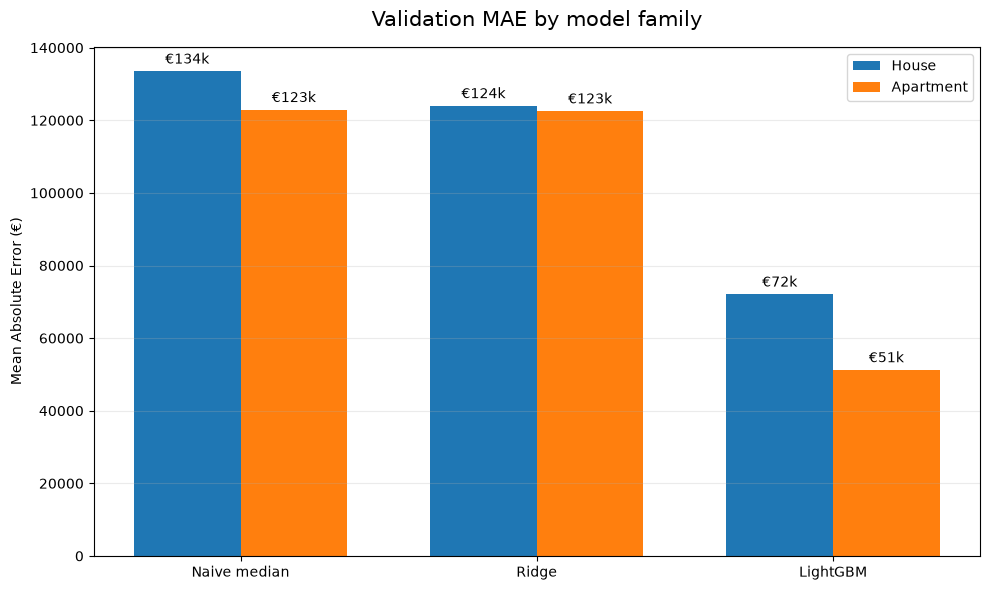

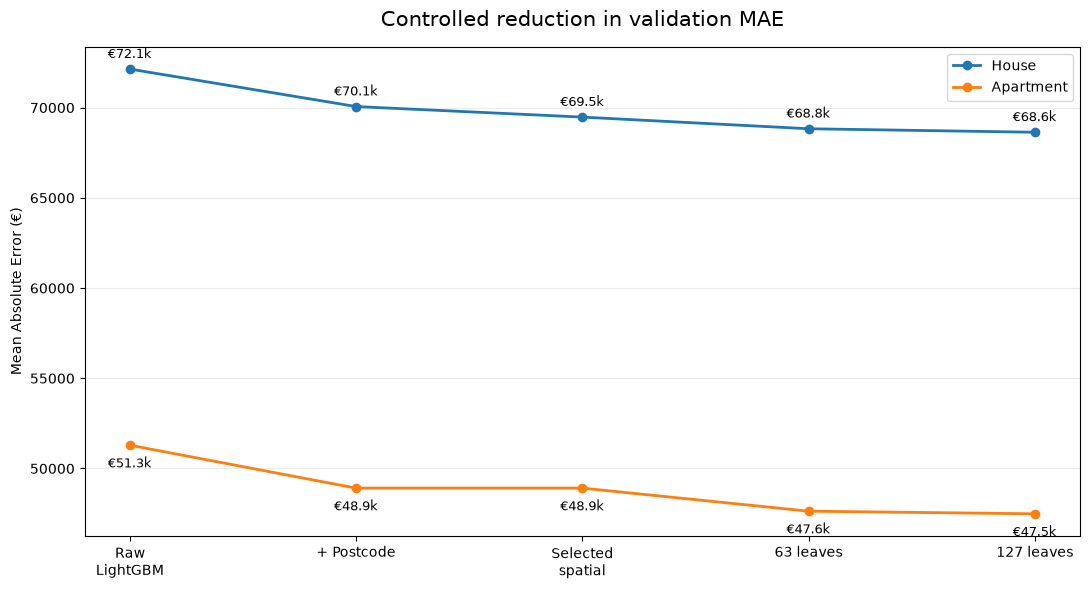

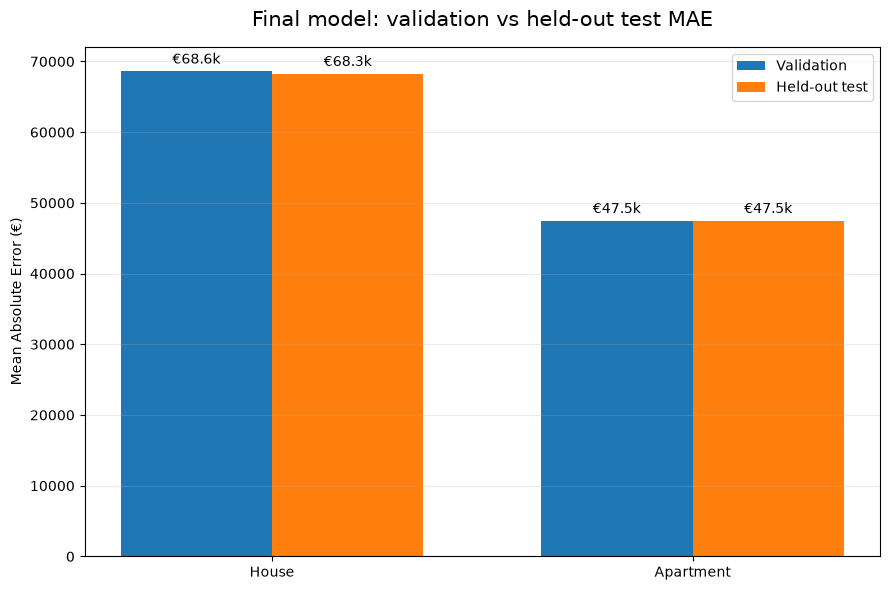

PRESENTATION FIGURES SAVED
c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\outputs\figures\model_family_validation_mae.png
c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\outputs\figures\model_development_validation_mae.png
c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\outputs\figures\validation_vs_test_mae.png


In [55]:
# ============================================================
# PRESENTATION FIGURES — FINAL MODELING RESULTS
# ============================================================
# PURPOSE:
# Create a small set of presentation-ready figures summarizing:
#
# 1. Why LightGBM was selected over the baselines.
# 2. How the final model improved through controlled development.
# 3. Whether validation performance was reproduced on the
#    untouched test set.
#
# IMPORTANT:
# - No model training occurs here.
# - No model selection occurs here.
# - These figures only visualize already-observed results.
# ============================================================


FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# FIGURE 1 — MODEL FAMILY COMPARISON
# ============================================================
# PURPOSE:
# Demonstrate quantitatively why the nonlinear LightGBM model
# was preferred over the naive median and Ridge baselines.
#
# We use validation MAE because model selection was performed
# on validation data, not test data.
# ============================================================

models = ["Naive median", "Ridge", "LightGBM"]
house_mae = [133559, 124039, 72137]
apartment_mae = [122966, 122592, 51291]

x = np.arange(len(models))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))

bars_house = ax.bar(
    x - width / 2,
    house_mae,
    width,
    label="House",
)

bars_apartment = ax.bar(
    x + width / 2,
    apartment_mae,
    width,
    label="Apartment",
)

ax.set_title(
    "Validation MAE by model family",
    fontsize=15,
    pad=15,
)

ax.set_ylabel("Mean Absolute Error (€)")
ax.set_xticks(x)
ax.set_xticklabels(models)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.bar_label(
    bars_house,
    labels=[f"€{v/1000:.0f}k" for v in house_mae],
    padding=3,
)

ax.bar_label(
    bars_apartment,
    labels=[f"€{v/1000:.0f}k" for v in apartment_mae],
    padding=3,
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "model_family_validation_mae.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# FIGURE 2 — CONTROLLED MODEL DEVELOPMENT
# ============================================================
# PURPOSE:
# Show how performance changed through the major justified
# modeling decisions.
#
# This is more informative than showing every experiment.
# It tells the jury the development story without clutter.
#
# All values below are VALIDATION MAE.
# ============================================================

stages = [
    "Raw\nLightGBM",
    "+ Postcode",
    "Selected\nspatial",
    "63 leaves",
    "127 leaves",
]

house_progression = [
    72137,
    70060,
    69475,
    68830,
    68636,
]

apartment_progression = [
    51291,
    48913,
    48913,  # postcode remained selected representation
    47635,
    47489,
]

x = np.arange(len(stages))

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    x,
    house_progression,
    marker="o",
    linewidth=2,
    label="House",
)

ax.plot(
    x,
    apartment_progression,
    marker="o",
    linewidth=2,
    label="Apartment",
)

ax.set_title(
    "Controlled reduction in validation MAE",
    fontsize=15,
    pad=15,
)

ax.set_ylabel("Mean Absolute Error (€)")
ax.set_xticks(x)
ax.set_xticklabels(stages)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend()

for i, value in enumerate(house_progression):
    ax.annotate(
        f"€{value/1000:.1f}k",
        (i, value),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

for i, value in enumerate(apartment_progression):
    ax.annotate(
        f"€{value/1000:.1f}k",
        (i, value),
        xytext=(0, -16),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "model_development_validation_mae.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# FIGURE 3 — VALIDATION VS UNTOUCHED TEST
# ============================================================
# PURPOSE:
# Show that the final validation performance was reproduced
# on the held-out test set.
#
# This is one of the strongest final-model credibility figures.
# ============================================================

property_types = ["House", "Apartment"]

validation_mae = [
    68636.3686,
    47489.1,
]

test_mae = [
    house_test_metrics["MAE"],
    apartment_test_metrics["MAE"],
]

x = np.arange(len(property_types))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 6))

bars_validation = ax.bar(
    x - width / 2,
    validation_mae,
    width,
    label="Validation",
)

bars_test = ax.bar(
    x + width / 2,
    test_mae,
    width,
    label="Held-out test",
)

ax.set_title(
    "Final model: validation vs held-out test MAE",
    fontsize=15,
    pad=15,
)

ax.set_ylabel("Mean Absolute Error (€)")
ax.set_xticks(x)
ax.set_xticklabels(property_types)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.bar_label(
    bars_validation,
    labels=[
        f"€{v/1000:.1f}k"
        for v in validation_mae
    ],
    padding=3,
)

ax.bar_label(
    bars_test,
    labels=[
        f"€{v/1000:.1f}k"
        for v in test_mae
    ],
    padding=3,
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "validation_vs_test_mae.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


print("=" * 65)
print("PRESENTATION FIGURES SAVED")
print("=" * 65)

for filename in [
    "model_family_validation_mae.png",
    "model_development_validation_mae.png",
    "validation_vs_test_mae.png",
]:
    print(FIGURES_DIR / filename)

# Production inference artifact

The final models have been selected and evaluated on the held-out test sets.

The next step packages the frozen models together with every transformation and
piece of metadata required to reproduce inference outside the notebook.

The objective is to ensure that the future FastAPI service can transform a new
property in exactly the same way as the validated notebook pipeline.

No model selection or test-driven tuning occurs in this section.

In [58]:
# ============================================================
# PRODUCTION ARTIFACT — PRE-SERIALIZATION AUDIT
# ============================================================
# PURPOSE:
# Verify every object required to reproduce the final inference
# pipeline BEFORE creating model.pkl.
#
# Nothing is trained, fitted, or modified in this cell.
# ============================================================



print("=" * 70)
print("PRODUCTION ARTIFACT — PRE-SERIALIZATION AUDIT")
print("=" * 70)


# ------------------------------------------------------------
# 1. Final model objects
# ------------------------------------------------------------

print("\nFINAL MODELS")
print("-" * 70)

for name, model in [
    ("house_lgbm_127", house_lgbm_127),
    ("apartment_lgbm_127", apartment_lgbm_127),
]:
    print(f"\n{name}")
    print("Type:", type(model))
    print("Fitted:", hasattr(model, "booster_"))
    print("n_features_in_:", getattr(model, "n_features_in_", None))
    print("best_iteration_:", getattr(model, "best_iteration_", None))
    print("num_leaves:", model.get_params().get("num_leaves"))
    print("n_estimators:", model.get_params().get("n_estimators"))


# ------------------------------------------------------------
# 2. Exact final feature contracts
# ------------------------------------------------------------

HOUSE_FEATURES = X_house_train_combined.columns.tolist()
APARTMENT_FEATURES = X_apartment_train_postcode.columns.tolist()

print("\n" + "=" * 70)
print("FEATURE CONTRACTS")
print("=" * 70)

print("\nHOUSE:")
print(HOUSE_FEATURES)

print("\nAPARTMENT:")
print(APARTMENT_FEATURES)


# ------------------------------------------------------------
# 3. Training-fitted categorical vocabularies
# ------------------------------------------------------------

HOUSE_POSTCODE_CATEGORIES = (
    X_house_train_combined["code_postal"]
    .cat.categories
    .tolist()
)

HOUSE_NEIGHBORHOOD_CATEGORIES = (
    X_house_train_combined["virtual_neighborhood"]
    .cat.categories
    .tolist()
)

APARTMENT_POSTCODE_CATEGORIES = (
    X_apartment_train_postcode["code_postal"]
    .cat.categories
    .tolist()
)

print("\n" + "=" * 70)
print("CATEGORICAL VOCABULARIES")
print("=" * 70)

print(
    "House postcode categories:",
    len(HOUSE_POSTCODE_CATEGORIES),
)

print(
    "House virtual-neighborhood categories:",
    len(HOUSE_NEIGHBORHOOD_CATEGORIES),
)

print(
    "Apartment postcode categories:",
    len(APARTMENT_POSTCODE_CATEGORIES),
)

print(
    "\nHouse postcode category type:",
    type(HOUSE_POSTCODE_CATEGORIES[0]),
)

print(
    "House neighborhood category type:",
    type(HOUSE_NEIGHBORHOOD_CATEGORIES[0]),
)

print(
    "Apartment postcode category type:",
    type(APARTMENT_POSTCODE_CATEGORIES[0]),
)


# ------------------------------------------------------------
# 4. Frozen spatial representation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("HOUSE SPATIAL REPRESENTATION")
print("=" * 70)

print("Cluster centers shape:", cluster_centers.shape)
print("Cluster centers dtype:", cluster_centers.dtype)

print(
    "All cluster centers finite:",
    np.isfinite(cluster_centers).all(),
)

print("\nLambert transformer:")
print(lambert93_transformer)


# ------------------------------------------------------------
# 5. Package/library versions
#
# These will be stored as artifact metadata. They are useful
# later when reproducing the model in FastAPI / Hugging Face.
# ------------------------------------------------------------

VERSIONS = {
    "lightgbm": lgb.__version__,
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "pyproj": pyproj.__version__,
}

print("\n" + "=" * 70)
print("LIBRARY VERSIONS")
print("=" * 70)

for package, version in VERSIONS.items():
    print(f"{package}: {version}")


# ------------------------------------------------------------
# 6. Final integrity assertions
# ------------------------------------------------------------

assert HOUSE_FEATURES == [
    "surface_habitable",
    "n_pieces",
    "vefa",
    "latitude",
    "longitude",
    "code_postal",
    "virtual_neighborhood",
]

assert APARTMENT_FEATURES == [
    "surface_habitable",
    "n_pieces",
    "vefa",
    "latitude",
    "longitude",
    "code_postal",
]

assert cluster_centers.shape == (2000, 2)
assert np.isfinite(cluster_centers).all()

assert len(HOUSE_POSTCODE_CATEGORIES) > 0
assert len(APARTMENT_POSTCODE_CATEGORIES) > 0
assert len(HOUSE_NEIGHBORHOOD_CATEGORIES) == 2000

assert hasattr(house_lgbm_127, "booster_")
assert hasattr(apartment_lgbm_127, "booster_")


print("\n" + "=" * 70)
print("PRE-SERIALIZATION AUDIT PASSED")
print("=" * 70)

print(
    "All objects required for production inference "
    "are available."
)

PRODUCTION ARTIFACT — PRE-SERIALIZATION AUDIT

FINAL MODELS
----------------------------------------------------------------------

house_lgbm_127
Type: <class 'lightgbm.sklearn.LGBMRegressor'>
Fitted: True
n_features_in_: 7
best_iteration_: 5000
num_leaves: 127
n_estimators: 5000

apartment_lgbm_127
Type: <class 'lightgbm.sklearn.LGBMRegressor'>
Fitted: True
n_features_in_: 6
best_iteration_: 3752
num_leaves: 127
n_estimators: 5000

FEATURE CONTRACTS

HOUSE:
['surface_habitable', 'n_pieces', 'vefa', 'latitude', 'longitude', 'code_postal', 'virtual_neighborhood']

APARTMENT:
['surface_habitable', 'n_pieces', 'vefa', 'latitude', 'longitude', 'code_postal']

CATEGORICAL VOCABULARIES
House postcode categories: 5631
House virtual-neighborhood categories: 2000
Apartment postcode categories: 4856

House postcode category type: <class 'str'>
House neighborhood category type: <class 'int'>
Apartment postcode category type: <class 'str'>

HOUSE SPATIAL REPRESENTATION
Cluster centers shape: (200

In [59]:
# ============================================================
# PRODUCTION INFERENCE WRAPPER — CONSTRUCTION
# ============================================================
# PURPOSE:
# Instantiate the production inference wrapper using ONLY
# frozen training-derived objects and the already-fitted final
# LightGBM models.
#
# No model fitting occurs here.
# ============================================================

import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.inference import PropertyValuationModel


production_model = PropertyValuationModel(
    house_model=house_lgbm_127,
    apartment_model=apartment_lgbm_127,

    house_postcode_categories=(
        HOUSE_POSTCODE_CATEGORIES
    ),

    apartment_postcode_categories=(
        APARTMENT_POSTCODE_CATEGORIES
    ),

    house_neighborhood_categories=(
        HOUSE_NEIGHBORHOOD_CATEGORIES
    ),

    cluster_centers=cluster_centers,
)


print("=" * 70)
print("PRODUCTION INFERENCE WRAPPER CREATED")
print("=" * 70)

print(
    "House features:",
    production_model.HOUSE_FEATURES,
)

print(
    "Apartment features:",
    production_model.APARTMENT_FEATURES,
)

print(
    "House postcode vocabulary:",
    len(
        production_model.house_postcode_categories
    ),
)

print(
    "Apartment postcode vocabulary:",
    len(
        production_model.apartment_postcode_categories
    ),
)

print(
    "Virtual neighborhoods:",
    len(
        production_model.house_neighborhood_categories
    ),
)

print(
    "Cluster centers:",
    production_model.cluster_centers.shape,
)

PRODUCTION INFERENCE WRAPPER CREATED
House features: ['surface_habitable', 'n_pieces', 'vefa', 'latitude', 'longitude', 'code_postal', 'virtual_neighborhood']
Apartment features: ['surface_habitable', 'n_pieces', 'vefa', 'latitude', 'longitude', 'code_postal']
House postcode vocabulary: 5631
Apartment postcode vocabulary: 4856
Virtual neighborhoods: 2000
Cluster centers: (2000, 2)


In [60]:
# ============================================================
# PRODUCTION INFERENCE — EQUIVALENCE TEST
# ============================================================
# PURPOSE:
# Verify that the production inference wrapper reproduces the
# predictions from the exact final notebook feature matrices.
#
# This is NOT a new model evaluation:
# - no fitting occurs;
# - no hyperparameter is changed;
# - no model selection occurs;
# - no test metric is used.
#
# We simply verify:
#
# notebook feature matrix -> final model
#               ==
# raw property fields -> production wrapper -> final model
#
# If these predictions match to floating-point tolerance,
# production preprocessing is consistent with the validated
# notebook pipeline.
# ============================================================

import numpy as np
import pandas as pd


print("=" * 72)
print("PRODUCTION INFERENCE — EQUIVALENCE TEST")
print("=" * 72)


# ------------------------------------------------------------
# 1. Select a small deterministic sample
# ------------------------------------------------------------
# We deliberately use only a handful of rows.
#
# The purpose is NOT statistical evaluation. We only need to
# test whether both inference paths produce the same values.
# ------------------------------------------------------------

N_EQUIVALENCE_ROWS = 10

house_indices = (
    house_test
    .head(N_EQUIVALENCE_ROWS)
    .index
)

apartment_indices = (
    apartment_test
    .head(N_EQUIVALENCE_ROWS)
    .index
)


# ------------------------------------------------------------
# 2. HOUSE — compare notebook vs production predictions
# ------------------------------------------------------------

house_notebook_predictions = (
    house_lgbm_127.predict(
        X_house_test.loc[house_indices]
    )
)

house_production_predictions = []

for idx in house_indices:

    raw_row = house_test.loc[idx]

    prediction = production_model.predict(
        property_type="house",
        surface_habitable=float(
            raw_row["surface_habitable"]
        ),
        n_pieces=(
            None
            if pd.isna(raw_row["n_pieces"])
            else float(raw_row["n_pieces"])
        ),
        vefa=bool(
            raw_row["vefa"]
        ),
        latitude=float(
            raw_row["latitude"]
        ),
        longitude=float(
            raw_row["longitude"]
        ),
        code_postal=raw_row["code_postal"],
    )

    house_production_predictions.append(
        prediction
    )

house_production_predictions = np.asarray(
    house_production_predictions
)


# ------------------------------------------------------------
# 3. APARTMENT — compare notebook vs production predictions
# ------------------------------------------------------------

apartment_notebook_predictions = (
    apartment_lgbm_127.predict(
        X_apartment_test.loc[apartment_indices]
    )
)

apartment_production_predictions = []

for idx in apartment_indices:

    raw_row = apartment_test.loc[idx]

    prediction = production_model.predict(
        property_type="apartment",
        surface_habitable=float(
            raw_row["surface_habitable"]
        ),
        n_pieces=(
            None
            if pd.isna(raw_row["n_pieces"])
            else float(raw_row["n_pieces"])
        ),
        vefa=bool(
            raw_row["vefa"]
        ),
        latitude=float(
            raw_row["latitude"]
        ),
        longitude=float(
            raw_row["longitude"]
        ),
        code_postal=raw_row["code_postal"],
    )

    apartment_production_predictions.append(
        prediction
    )

apartment_production_predictions = np.asarray(
    apartment_production_predictions
)


# ------------------------------------------------------------
# 4. Calculate absolute prediction differences
# ------------------------------------------------------------

house_differences = np.abs(
    house_notebook_predictions
    - house_production_predictions
)

apartment_differences = np.abs(
    apartment_notebook_predictions
    - apartment_production_predictions
)


# ------------------------------------------------------------
# 5. Display row-level comparison
# ------------------------------------------------------------

house_comparison = pd.DataFrame(
    {
        "notebook_prediction":
            house_notebook_predictions,

        "production_prediction":
            house_production_predictions,

        "absolute_difference":
            house_differences,
    }
)

apartment_comparison = pd.DataFrame(
    {
        "notebook_prediction":
            apartment_notebook_predictions,

        "production_prediction":
            apartment_production_predictions,

        "absolute_difference":
            apartment_differences,
    }
)


print("\nHOUSE")
print("-" * 72)
print(house_comparison.to_string(index=False))


print("\nAPARTMENT")
print("-" * 72)
print(apartment_comparison.to_string(index=False))


# ------------------------------------------------------------
# 6. Numerical equivalence assertions
# ------------------------------------------------------------
# atol=1e-6 euros is far below any meaningful valuation
# precision and allows only insignificant floating-point noise.
# ------------------------------------------------------------

HOUSE_EQUIVALENT = np.allclose(
    house_notebook_predictions,
    house_production_predictions,
    rtol=0.0,
    atol=1e-6,
)

APARTMENT_EQUIVALENT = np.allclose(
    apartment_notebook_predictions,
    apartment_production_predictions,
    rtol=0.0,
    atol=1e-6,
)


print("\n" + "=" * 72)
print("EQUIVALENCE SUMMARY")
print("=" * 72)

print(
    "House maximum absolute difference:",
    f"{house_differences.max():.12f} €",
)

print(
    "Apartment maximum absolute difference:",
    f"{apartment_differences.max():.12f} €",
)

print(
    "House equivalent:",
    HOUSE_EQUIVALENT,
)

print(
    "Apartment equivalent:",
    APARTMENT_EQUIVALENT,
)


assert HOUSE_EQUIVALENT, (
    "House production inference does not reproduce "
    "the notebook predictions."
)

assert APARTMENT_EQUIVALENT, (
    "Apartment production inference does not reproduce "
    "the notebook predictions."
)


print("\n" + "=" * 72)
print("PRODUCTION INFERENCE EQUIVALENCE TEST PASSED")
print("=" * 72)

PRODUCTION INFERENCE — EQUIVALENCE TEST

HOUSE
------------------------------------------------------------------------
 notebook_prediction  production_prediction  absolute_difference
       431159.313969          431159.313969                  0.0
       147689.837305          147689.837305                  0.0
       253637.356558          253637.356558                  0.0
       137995.842793          137995.842793                  0.0
       175918.580660          175918.580660                  0.0
       207962.878202          207962.878202                  0.0
       218434.279740          218434.279740                  0.0
       250397.110741          250397.110741                  0.0
       240416.831713          240416.831713                  0.0
       187525.906381          187525.906381                  0.0

APARTMENT
------------------------------------------------------------------------
 notebook_prediction  production_prediction  absolute_difference
       662967.05

In [62]:
# ============================================================
# PRODUCTION ARTIFACT — SERIALIZE AND RELOAD model.pkl
# ============================================================
# PURPOSE:
# 1. Serialize the validated production inference wrapper.
# 2. Reload it from disk.
# 3. Verify that the DESERIALIZED artifact still produces the
#    same predictions as the in-memory production wrapper.
#
# This is the exact artifact that will later be uploaded to S3
# and loaded by the FastAPI service.
#
# No model training or fitting occurs here.
# ============================================================


# ------------------------------------------------------------
# 1. Artifact location
# ------------------------------------------------------------
# The outputs/models directory is local/generated output.
# model.pkl must NOT be committed to Git.
# ------------------------------------------------------------

MODEL_DIR = PROJECT_ROOT / "outputs" / "models"
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_PATH = MODEL_DIR / "model.pkl"


# ------------------------------------------------------------
# 2. Serialize the complete production wrapper
# ------------------------------------------------------------

joblib.dump(
    production_model,
    MODEL_PATH,
)


print("=" * 72)
print("PRODUCTION ARTIFACT SERIALIZED")
print("=" * 72)

print("Path:", MODEL_PATH)
print(
    "Size:",
    f"{MODEL_PATH.stat().st_size / (1024 ** 2):.2f} MB",
)


# ------------------------------------------------------------
# 3. Reload from disk
# ------------------------------------------------------------
# This is important:
# we now stop relying on the original in-memory object and
# verify that the saved artifact can reconstruct correctly.
# ------------------------------------------------------------

loaded_model = joblib.load(
    MODEL_PATH
)


print("\nReloaded object type:")
print(type(loaded_model))


# ------------------------------------------------------------
# 4. Use deterministic reference properties
# ------------------------------------------------------------
# We use the first previously-tested House and Apartment rows.
#
# The goal is NOT model evaluation.
# We are testing serialization fidelity only.
# ------------------------------------------------------------

house_reference_index = house_indices[0]
apartment_reference_index = apartment_indices[0]

house_reference = house_test.loc[
    house_reference_index
]

apartment_reference = apartment_test.loc[
    apartment_reference_index
]


# ------------------------------------------------------------
# 5. Original in-memory predictions
# ------------------------------------------------------------

house_before_serialization = (
    production_model.predict(
        property_type="house",

        surface_habitable=float(
            house_reference["surface_habitable"]
        ),

        n_pieces=(
            None
            if pd.isna(
                house_reference["n_pieces"]
            )
            else float(
                house_reference["n_pieces"]
            )
        ),

        vefa=bool(
            house_reference["vefa"]
        ),

        latitude=float(
            house_reference["latitude"]
        ),

        longitude=float(
            house_reference["longitude"]
        ),

        code_postal=(
            house_reference["code_postal"]
        ),
    )
)


apartment_before_serialization = (
    production_model.predict(
        property_type="apartment",

        surface_habitable=float(
            apartment_reference["surface_habitable"]
        ),

        n_pieces=(
            None
            if pd.isna(
                apartment_reference["n_pieces"]
            )
            else float(
                apartment_reference["n_pieces"]
            )
        ),

        vefa=bool(
            apartment_reference["vefa"]
        ),

        latitude=float(
            apartment_reference["latitude"]
        ),

        longitude=float(
            apartment_reference["longitude"]
        ),

        code_postal=(
            apartment_reference["code_postal"]
        ),
    )
)


# ------------------------------------------------------------
# 6. Predictions from RELOADED model.pkl
# ------------------------------------------------------------

house_after_serialization = (
    loaded_model.predict(
        property_type="house",

        surface_habitable=float(
            house_reference["surface_habitable"]
        ),

        n_pieces=(
            None
            if pd.isna(
                house_reference["n_pieces"]
            )
            else float(
                house_reference["n_pieces"]
            )
        ),

        vefa=bool(
            house_reference["vefa"]
        ),

        latitude=float(
            house_reference["latitude"]
        ),

        longitude=float(
            house_reference["longitude"]
        ),

        code_postal=(
            house_reference["code_postal"]
        ),
    )
)


apartment_after_serialization = (
    loaded_model.predict(
        property_type="apartment",

        surface_habitable=float(
            apartment_reference["surface_habitable"]
        ),

        n_pieces=(
            None
            if pd.isna(
                apartment_reference["n_pieces"]
            )
            else float(
                apartment_reference["n_pieces"]
            )
        ),

        vefa=bool(
            apartment_reference["vefa"]
        ),

        latitude=float(
            apartment_reference["latitude"]
        ),

        longitude=float(
            apartment_reference["longitude"]
        ),

        code_postal=(
            apartment_reference["code_postal"]
        ),
    )
)


# ------------------------------------------------------------
# 7. Serialization equivalence
# ------------------------------------------------------------

house_difference = abs(
    house_before_serialization
    - house_after_serialization
)

apartment_difference = abs(
    apartment_before_serialization
    - apartment_after_serialization
)


print("\n" + "=" * 72)
print("SERIALIZATION EQUIVALENCE")
print("=" * 72)

print("\nHOUSE")
print(
    "Before serialization:",
    f"€{house_before_serialization:,.6f}",
)
print(
    "After reload:",
    f"€{house_after_serialization:,.6f}",
)
print(
    "Absolute difference:",
    f"{house_difference:.12f} €",
)


print("\nAPARTMENT")
print(
    "Before serialization:",
    f"€{apartment_before_serialization:,.6f}",
)
print(
    "After reload:",
    f"€{apartment_after_serialization:,.6f}",
)
print(
    "Absolute difference:",
    f"{apartment_difference:.12f} €",
)


# ------------------------------------------------------------
# 8. Strict integrity assertions
# ------------------------------------------------------------

assert np.isclose(
    house_before_serialization,
    house_after_serialization,
    rtol=0.0,
    atol=1e-6,
), (
    "House prediction changed after serialization."
)

assert np.isclose(
    apartment_before_serialization,
    apartment_after_serialization,
    rtol=0.0,
    atol=1e-6,
), (
    "Apartment prediction changed after serialization."
)


assert MODEL_PATH.exists()
assert MODEL_PATH.stat().st_size > 0


print("\n" + "=" * 72)
print("PRODUCTION model.pkl VALIDATED")
print("=" * 72)

print(
    "The serialized artifact reproduces the "
    "validated production inference behavior."
)

PRODUCTION ARTIFACT SERIALIZED
Path: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\outputs\models\model.pkl
Size: 336.74 MB

Reloaded object type:
<class 'src.inference.PropertyValuationModel'>

SERIALIZATION EQUIVALENCE

HOUSE
Before serialization: €431,159.313969
After reload: €431,159.313969
Absolute difference: 0.000000000000 €

APARTMENT
Before serialization: €662,967.058010
After reload: €662,967.058010
Absolute difference: 0.000000000000 €

PRODUCTION model.pkl VALIDATED
The serialized artifact reproduces the validated production inference behavior.
